In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 64
==================================================

Week: 10 of 24
Day: 64 of 168
Date: Sunday, January 4, 2026
Topic: Reinforcement Learning Fundamentals


Week 10 Progress:
🔄 Day 64: RL Fundamentals - MDP, Value Functions, Bellman Equations (TODAY!)
⬜ Day 65: Q-Learning & Temporal Difference Learning
⬜ Day 66: Deep Q-Networks (DQN) Theory
⬜ Day 67: DQN Implementation & CartPole
⬜ Day 68: DQN Training & Optimization
⬜ Day 69: LunarLander Environment Setup
⬜ Day 70: LunarLander DQN Training

Progress: 0% (0/7 days)

==================================================
🎯 Week 10 Project: Autonomous RL Agent with DQN
- Master Reinforcement Learning fundamentals from scratch
- Implement Deep Q-Networks (DQN) in PyTorch
- Train agent to solve CartPole and LunarLander environments
- Achieve 200+ average reward on LunarLander
- Build foundation for advanced RL algorithms (Week 11)

🎯 Today's Learning Objectives:
1. Understand Markov Decision Process (MDP) framework completely
   - States, Actions, Rewards, Transitions, Policy
   - Markov property and why it matters
   - MDP vs supervised learning fundamentals

2. Master Value Functions and Bellman Equations
   - State-value function V(s)
   - Action-value function Q(s,a)
   - Bellman optimality equations
   - Mathematical intuition and practical meaning

3. Implement Tabular Q-Learning from scratch
   - Build simple GridWorld environment
   - Q-table initialization and updates
   - Exploration vs Exploitation (epsilon-greedy)
   - Visualize learning process and convergence

4. Develop RL intuition through hands-on coding
   - See agent learn optimal policy step-by-step
   - Understand why RL is different from supervised learning
   - Build mental models for DQN (tomorrow!)

📚 Today's Structure:
Part 1 (2h): Markov Decision Process (MDP) Framework
Part 2 (2h): Value Functions & Bellman Equations
Part 3 (3h): Tabular Q-Learning Implementation (GridWorld)
Part 4 (1h): Summary, Visualizations & Next Steps

🎯 SUCCESS CRITERIA:
✅ Can explain MDP components (S, A, R, P, π) with examples
✅ Understand Bellman equations intuitively and mathematically
✅ Successfully implement Q-Learning algorithm from scratch
✅ Train agent to solve GridWorld (optimal path found)
✅ Visualize Q-values and policy convergence
✅ Ready for Deep Q-Networks tomorrow!

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================

import sys
!{sys.executable} -m pip install gymnasium numpy matplotlib seaborn pandas tqdm -q

print("✅ Libraries installed!")
print("\n" + "=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================

print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque
import random
from tqdm import tqdm
import time
import os

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Create results directory
os.makedirs('results/plots', exist_ok=True)
os.makedirs('results/models', exist_ok=True)

print("\n✅ All libraries imported successfully!")
print("=" * 80)
print(f"\n📊 NumPy version: {np.__version__}")
print(f"📊 Random seed set to: 42")
print(f"📁 Results directories created!")
print("=" * 80)

'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


✅ Libraries installed!


📚 IMPORTING LIBRARIES

✅ All libraries imported successfully!

📊 NumPy version: 2.3.5
📊 Random seed set to: 42
📁 Results directories created!


In [2]:
print("\n" + "=" * 80)
print("📚 PART 1: MARKOV DECISION PROCESS (MDP) FRAMEWORK")
print("=" * 80)


📚 PART 1: MARKOV DECISION PROCESS (MDP) FRAMEWORK


In [3]:
# ==================================================
# EXERCISE 1.1: WHAT IS REINFORCEMENT LEARNING?
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Understanding Reinforcement Learning")
print("=" * 80)

"""
📖 THEORY: What is Reinforcement Learning?

Reinforcement Learning (RL) is a type of machine learning where an agent learns
to make decisions by interacting with an environment. Unlike supervised learning
(which learns from labeled examples) or unsupervised learning (which finds patterns),
RL learns from trial and error through rewards and penalties.

Key Concepts:
- Agent: The learner/decision maker (our AI)
- Environment: The world the agent interacts with
- State: Current situation of the agent
- Action: What the agent can do
- Reward: Feedback signal (positive or negative)
- Policy: Strategy the agent uses to choose actions

Why this matters:
- RL can solve problems where we don't have labeled data
- Agents discover strategies we might not think of
- Works for sequential decision-making (games, robotics, self-driving cars)
- Can optimize long-term rewards, not just immediate gains
"""

print("\n🎮 Real-World RL Examples:")
print("=" * 80)

examples = {
    "Game Playing": {
        "Agent": "AI player",
        "Environment": "Game board/screen",
        "State": "Current game position",
        "Actions": "Moves the AI can make",
        "Reward": "+1 for winning, -1 for losing, 0 for draw",
        "Example": "AlphaGo, Chess engines, Atari games"
    },
    "Robotics": {
        "Agent": "Robot",
        "Environment": "Physical world",
        "State": "Robot's position, sensor readings",
        "Actions": "Motor commands (move forward, turn, grasp)",
        "Reward": "+1 for completing task, -1 for collisions",
        "Example": "Robot navigation, manipulation tasks"
    },
    "Self-Driving Cars": {
        "Agent": "Autonomous vehicle",
        "Environment": "Roads, traffic, weather",
        "State": "Camera images, LIDAR, GPS position",
        "Actions": "Steer, accelerate, brake",
        "Reward": "+1 for safe driving, -100 for accidents",
        "Example": "Tesla Autopilot, Waymo"
    },
    "Recommendation Systems": {
        "Agent": "Recommendation algorithm",
        "Environment": "User interactions",
        "State": "User history, current context",
        "Actions": "Which items to recommend",
        "Reward": "+1 for clicks/purchases, 0 for ignores",
        "Example": "Netflix, YouTube, TikTok"
    }
}

for domain, details in examples.items():
    print(f"\n🎯 {domain}:")
    for key, value in details.items():
        print(f"   • {key}: {value}")

print("\n" + "=" * 80)
print("💡 KEY INSIGHT:")
print("=" * 80)
print("""
RL is fundamentally different from supervised learning:

Supervised Learning:
- Learns from labeled examples (input → correct output)
- Teacher tells you the right answer
- Goal: Minimize error on training data
- Example: "This X-ray shows pneumonia" → Learn to classify

Reinforcement Learning:
- Learns from rewards/penalties (action → reward)
- No teacher, just feedback on how well you did
- Goal: Maximize cumulative reward over time
- Example: "You moved here and won the game!" → Learn to play

The agent must explore to discover good strategies!
""")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Understanding Reinforcement Learning

🎮 Real-World RL Examples:

🎯 Game Playing:
   • Agent: AI player
   • Environment: Game board/screen
   • State: Current game position
   • Actions: Moves the AI can make
   • Reward: +1 for winning, -1 for losing, 0 for draw
   • Example: AlphaGo, Chess engines, Atari games

🎯 Robotics:
   • Agent: Robot
   • Environment: Physical world
   • State: Robot's position, sensor readings
   • Actions: Motor commands (move forward, turn, grasp)
   • Reward: +1 for completing task, -1 for collisions
   • Example: Robot navigation, manipulation tasks

🎯 Self-Driving Cars:
   • Agent: Autonomous vehicle
   • Environment: Roads, traffic, weather
   • State: Camera images, LIDAR, GPS position
   • Actions: Steer, accelerate, brake
   • Reward: +1 for safe driving, -100 for accidents
   • Example: Tesla Autopilot, Waymo

🎯 Recommendation Systems:
   • Agent: Recommendation algorithm
   • Environment: User interactions
   • State: User history, c

In [5]:
# ==================================================
# EXERCISE 1.2: MARKOV DECISION PROCESS (MDP) COMPONENTS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: The MDP Framework")
print("=" * 80)

"""
📖 THEORY: Markov Decision Process (MDP)

An MDP is a mathematical framework for modeling decision-making in situations
where outcomes are partly random and partly under the control of a decision maker.

An MDP is defined by a 5-tuple: (S, A, P, R, γ)

Components:
1. S = State space (all possible situations)
2. A = Action space (all possible actions)
3. P = Transition probability P(s'|s,a) - probability of reaching state s' from state s after action a
4. R = Reward function R(s,a,s') - immediate reward for transition
5. γ (gamma) = Discount factor (0 ≤ γ ≤ 1) - how much we value future rewards

The Markov Property:
"The future is independent of the past given the present"
Mathematically: P(s_{t+1} | s_t, a_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t, a_t)

Why this matters:
- We only need the current state to make decisions
- Don't need to remember entire history
- Makes computation tractable
- Holds for most real-world problems (or can be engineered to hold)
"""

print("\n🎯 MDP Example: GridWorld Navigation")
print("=" * 80)

print("""
Imagine a robot navigating a 4x4 grid:

Grid Layout:
    0   1   2   3
  +---+---+---+---+
0 | S |   |   |   |  S = Start
  +---+---+---+---+  G = Goal (+10 reward)
1 |   | X |   |   |  X = Obstacle (-10 reward)
  +---+---+---+---+  Empty = -1 reward (cost of living)
2 |   |   |   | X |
  +---+---+---+---+
3 |   |   |   | G |
  +---+---+---+---+

MDP Components:
""")

mdp_components = {
    "States (S)": "All 16 grid positions: (0,0), (0,1), ..., (3,3)",
    "Actions (A)": "4 possible moves: UP, DOWN, LEFT, RIGHT",
    "Transitions (P)": "Deterministic: Action UP from (1,1) → (0,1) with 100% probability",
    "Rewards (R)": "+10 for reaching goal, -10 for obstacle, -1 for each step",
    "Discount (γ)": "0.99 (we care about future rewards, not just immediate)"
}

for component, description in mdp_components.items():
    print(f"\n📌 {component}:")
    print(f"   {description}")

print("\n" + "=" * 80)
print("🤔 Why Discount Factor γ?")
print("=" * 80)

print("""
Discount factor γ controls how much we value future rewards:

γ = 0:  Only care about immediate reward (myopic)
        → Take closest reward, ignore long-term consequences
        
γ = 0.5: Future rewards worth 50% of immediate rewards
        → Balance between short and long-term
        
γ = 0.99: Future rewards almost as valuable as immediate
        → Very forward-thinking, willing to sacrifice now for later
        
γ = 1:  Future rewards = present rewards (no discounting)
        → Can lead to infinite values in continuing tasks!

In practice: γ = 0.95 to 0.99 works well for most problems
""")

# Demonstrate discount factor effect
print("\n📊 Discount Factor Example:")
print("=" * 80)

immediate_reward = 10
gamma_values = [0.0, 0.5, 0.9, 0.99, 1.0]
steps_ahead = 5

print(f"\nImmediate reward: {immediate_reward}")
print(f"Reward {steps_ahead} steps in the future discounted by γ^{steps_ahead}:\n")

for gamma in gamma_values:
    discounted = immediate_reward * (gamma ** steps_ahead)
    print(f"γ = {gamma:4.2f} → Discounted reward = {discounted:6.2f}")

print("\n💡 Notice: Lower γ makes future rewards less valuable!")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.2: The MDP Framework

🎯 MDP Example: GridWorld Navigation

Imagine a robot navigating a 4x4 grid:

Grid Layout:
    0   1   2   3
  +---+---+---+---+
0 | S |   |   |   |  S = Start
  +---+---+---+---+  G = Goal (+10 reward)
1 |   | X |   |   |  X = Obstacle (-10 reward)
  +---+---+---+---+  Empty = -1 reward (cost of living)
2 |   |   |   | X |
  +---+---+---+---+
3 |   |   |   | G |
  +---+---+---+---+

MDP Components:


📌 States (S):
   All 16 grid positions: (0,0), (0,1), ..., (3,3)

📌 Actions (A):
   4 possible moves: UP, DOWN, LEFT, RIGHT

📌 Transitions (P):
   Deterministic: Action UP from (1,1) → (0,1) with 100% probability

📌 Rewards (R):
   +10 for reaching goal, -10 for obstacle, -1 for each step

📌 Discount (γ):
   0.99 (we care about future rewards, not just immediate)

🤔 Why Discount Factor γ?

Discount factor γ controls how much we value future rewards:

γ = 0:  Only care about immediate reward (myopic)
        → Take closest reward, ignore long-term consequen

In [6]:
# ==================================================
# EXERCISE 1.3: POLICY AND TRAJECTORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.3: Policy and Trajectory")
print("=" * 80)

"""
📖 THEORY: Policy

A policy π is the agent's strategy - it maps states to actions.

Two types of policies:
1. Deterministic Policy: π(s) = a
   - Always takes the same action in a given state
   - Example: "In state (1,1), always go RIGHT"

2. Stochastic Policy: π(a|s) = probability of action a in state s
   - Samples actions from a probability distribution
   - Example: "In state (1,1), go RIGHT 70%, UP 30%"

Goal of RL: Find the optimal policy π* that maximizes expected cumulative reward

Trajectory (Episode):
A sequence of states, actions, and rewards:
τ = (s_0, a_0, r_1, s_1, a_1, r_2, s_2, a_2, r_3, ..., s_T)

Why this matters:
- The policy is what we're trying to learn
- A good policy leads to high rewards
- We learn by trying different policies and seeing which works best
"""

print("\n🎯 Policy Examples:")
print("=" * 80)

print("""
Example 1: Random Policy (Baseline)
   π(a|s) = 1/4 for all actions (UP, DOWN, LEFT, RIGHT)
   → Chooses randomly, often gets stuck or hits obstacles
   → Expected return: LOW (but explores everywhere)

Example 2: Greedy Policy (Towards Goal)
   π(s) = action that moves closer to goal
   → Always moves in direction of goal
   → Problem: Might hit obstacles, doesn't consider long-term
   → Expected return: MEDIUM

Example 3: Optimal Policy (Learned)
   π*(s) = action that maximizes long-term reward
   → Avoids obstacles, finds shortest safe path
   → Considers future rewards, not just immediate
   → Expected return: HIGH (this is what we want!)
""")

print("\n📊 Trajectory Example:")
print("=" * 80)

print("""
Starting from (0,0), agent follows a policy for 5 steps:

Step | State  | Action | Reward | Next State
-----|--------|--------|--------|------------
  0  | (0,0)  | RIGHT  |   -1   | (0,1)
  1  | (0,1)  | RIGHT  |   -1   | (0,2)
  2  | (0,2)  | DOWN   |   -1   | (1,2)
  3  | (1,2)  | DOWN   |   -1   | (2,2)
  4  | (2,2)  | RIGHT  |   -1   | (2,3)
  5  | (2,3)  | DOWN   |  -10   | (2,3) [Hit obstacle!]

Total Return: -1 + -1 + -1 + -1 + -1 + -10 = -15
Not a good policy! 😞
""")

print("\n💡 KEY INSIGHT:")
print("=" * 80)
print("""
The goal of Reinforcement Learning is to find the optimal policy π* that:
- Maximizes the expected cumulative reward (return)
- Generalizes to unseen states
- Balances exploration (trying new things) vs exploitation (using what works)

We'll learn this optimal policy through experience!
""")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.3: Policy and Trajectory

🎯 Policy Examples:

Example 1: Random Policy (Baseline)
   π(a|s) = 1/4 for all actions (UP, DOWN, LEFT, RIGHT)
   → Chooses randomly, often gets stuck or hits obstacles
   → Expected return: LOW (but explores everywhere)

Example 2: Greedy Policy (Towards Goal)
   π(s) = action that moves closer to goal
   → Always moves in direction of goal
   → Problem: Might hit obstacles, doesn't consider long-term
   → Expected return: MEDIUM

Example 3: Optimal Policy (Learned)
   π*(s) = action that maximizes long-term reward
   → Avoids obstacles, finds shortest safe path
   → Considers future rewards, not just immediate
   → Expected return: HIGH (this is what we want!)


📊 Trajectory Example:

Starting from (0,0), agent follows a policy for 5 steps:

Step | State  | Action | Reward | Next State
-----|--------|--------|--------|------------
  0  | (0,0)  | RIGHT  |   -1   | (0,1)
  1  | (0,1)  | RIGHT  |   -1   | (0,2)
  2  | (0,2)  | DOWN   |   -1   | (1

In [7]:
# ==================================================
# EXERCISE 1.4: RETURN AND VALUE FUNCTIONS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.4: Return and Value Functions")
print("=" * 80)

"""
📖 THEORY: Return (Cumulative Reward)

The return G_t is the total discounted reward from time step t onwards:

G_t = r_{t+1} + γ*r_{t+2} + γ^2*r_{t+3} + γ^3*r_{t+4} + ...
    = r_{t+1} + γ*G_{t+1}  (recursive definition!)
    = Σ γ^k * r_{t+k+1}    (from k=0 to infinity)

Where:
- r_{t+1} is the immediate reward after action at time t
- γ is the discount factor (0 ≤ γ < 1)
- Future rewards are worth less than immediate rewards

Value Functions measure "how good" a state or action is:

1. State-Value Function V^π(s):
   V^π(s) = E_π[G_t | s_t = s]
   "Expected return starting from state s and following policy π"

2. Action-Value Function Q^π(s,a):
   Q^π(s,a) = E_π[G_t | s_t = s, a_t = a]
   "Expected return starting from state s, taking action a, then following policy π"

Why this matters:
- Return measures total reward (what we want to maximize)
- Value functions help us evaluate states and actions
- We can compare policies by comparing their value functions
- Q-values directly tell us which action is best!
"""

print("\n📊 Return Calculation Example:")
print("=" * 80)

# Simulate a trajectory
rewards = [10, -2, -2, -2, 100]  # Rewards received over 5 steps
gamma = 0.9

print(f"Trajectory rewards: {rewards}")
print(f"Discount factor γ = {gamma}\n")

# Calculate return at each timestep
for t in range(len(rewards)):
    future_rewards = rewards[t:]
    G_t = sum([gamma**k * r for k, r in enumerate(future_rewards)])
    
    print(f"Return at t={t}:")
    calculation = " + ".join([f"{gamma**k:.3f}*{r}" for k, r in enumerate(future_rewards)])
    print(f"  G_{t} = {calculation}")
    print(f"  G_{t} = {G_t:.2f}\n")

print("=" * 80)
print("💡 Notice how returns decrease as we go forward (less future reward left)")
print("=" * 80)

print("\n🎯 Value Function Intuition:")
print("=" * 80)

print("""
Imagine GridWorld states with their values:

    0      1      2      3
  +------+------+------+------+
0 | 5.2  | 6.1  | 7.3  | 8.5  |
  +------+------+------+------+
1 | 4.3  | -10  | 8.2  | 9.1  |  Higher values = better states
  +------+------+------+------+  (closer to goal, fewer obstacles)
2 | 3.1  | 3.8  | 8.9  | -10  |
  +------+------+------+------+
3 | 2.0  | 2.5  | 7.2  | +10  |
  +------+------+------+------+

The value of each state tells us:
- State (3,3) has V = 10 (at goal!)
- State (0,0) has V = 5.2 (far from goal, but safe path exists)
- State (1,1) has V = -10 (obstacle! avoid!)

If we know the values, we can act greedily:
→ Always move to the neighboring state with highest value
→ This gives us an optimal policy!
""")

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)


EXERCISE 1.4: Return and Value Functions

📊 Return Calculation Example:
Trajectory rewards: [10, -2, -2, -2, 100]
Discount factor γ = 0.9

Return at t=0:
  G_0 = 1.000*10 + 0.900*-2 + 0.810*-2 + 0.729*-2 + 0.656*100
  G_0 = 70.73

Return at t=1:
  G_1 = 1.000*-2 + 0.900*-2 + 0.810*-2 + 0.729*100
  G_1 = 67.48

Return at t=2:
  G_2 = 1.000*-2 + 0.900*-2 + 0.810*100
  G_2 = 77.20

Return at t=3:
  G_3 = 1.000*-2 + 0.900*100
  G_3 = 88.00

Return at t=4:
  G_4 = 1.000*100
  G_4 = 100.00

💡 Notice how returns decrease as we go forward (less future reward left)

🎯 Value Function Intuition:

Imagine GridWorld states with their values:

    0      1      2      3
  +------+------+------+------+
0 | 5.2  | 6.1  | 7.3  | 8.5  |
  +------+------+------+------+
1 | 4.3  | -10  | 8.2  | 9.1  |  Higher values = better states
  +------+------+------+------+  (closer to goal, fewer obstacles)
2 | 3.1  | 3.8  | 8.9  | -10  |
  +------+------+------+------+
3 | 2.0  | 2.5  | 7.2  | +10  |
  +------+--

In [8]:
print("\n" + "=" * 80)
print("📊 PART 2: VALUE FUNCTIONS & BELLMAN EQUATIONS")
print("=" * 80)


📊 PART 2: VALUE FUNCTIONS & BELLMAN EQUATIONS


In [9]:
# ==================================================
# EXERCISE 2.1: BELLMAN EQUATIONS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.1: Understanding Bellman Equations")
print("=" * 80)

"""
📖 THEORY: Bellman Equations

The Bellman equations express a fundamental recursive relationship:
"The value of a state equals the immediate reward plus the discounted value of the next state"

1. Bellman Expectation Equation for V^π(s):
   V^π(s) = Σ_a π(a|s) * Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ*V^π(s')]
   
   In words:
   "Value of state s = Expected immediate reward + Discounted value of next state"

2. Bellman Expectation Equation for Q^π(s,a):
   Q^π(s,a) = Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ*Σ_{a'} π(a'|s')*Q^π(s',a')]
   
   In words:
   "Q-value of (s,a) = Expected immediate reward + Discounted Q-value of next (s',a')"

3. Bellman Optimality Equation for V*(s):
   V*(s) = max_a Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ*V*(s')]
   
   In words:
   "Optimal value = Best action's expected [immediate reward + discounted next value]"

4. Bellman Optimality Equation for Q*(s,a):
   Q*(s,a) = Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ*max_{a'} Q*(s',a')]
   
   In words:
   "Optimal Q-value = Expected [immediate reward + discounted best next Q-value]"

Why this matters:
- These equations are the foundation of ALL RL algorithms
- They let us break down the problem recursively
- We can iteratively improve our value estimates
- Q-learning, DQN, and all modern RL methods use these!
"""

print("\n🎯 Bellman Equation Intuition:")
print("=" * 80)

print("""
Think of planning a road trip:

Question: "How long to get from San Francisco to New York?"

Bellman thinking:
1. Drive to next city (immediate cost: 3 hours)
2. From there, optimal time to New York is 37 hours
3. Total: 3 + 37 = 40 hours

This is exactly what Bellman equations do!
V(San Francisco) = cost_to_next_city + V(next_city)

The recursive structure lets us solve complex problems by breaking them down.
""")

print("\n📊 Bellman Equation Example (GridWorld):")
print("=" * 80)

print("""
Let's calculate V^π(s) for state (0,1) with a random policy (π = 0.25 for each action)

Grid (rewards):
    0      1      2      3
  +------+------+------+------+
0 | -1   | HERE | -1   | -1   |
  +------+------+------+------+
1 | -1   | -10  | -1   | -1   |
  +------+------+------+------+

Assume we know values of neighboring states:
V(0,0) = 5.0
V(0,2) = 7.0
V(1,1) = -10.0
V(0,1) = ? (what we want to find)

Using Bellman equation:
V(0,1) = Σ_a π(a|s) * [R(s,a) + γ*V(s')]

Breaking it down by action (γ = 0.9):

Action LEFT → State (0,0):
  0.25 * [-1 + 0.9*V(0,0)] = 0.25 * [-1 + 0.9*5.0] = 0.25 * 3.5 = 0.875

Action RIGHT → State (0,2):
  0.25 * [-1 + 0.9*V(0,2)] = 0.25 * [-1 + 0.9*7.0] = 0.25 * 5.3 = 1.325

Action DOWN → State (1,1):
  0.25 * [-10 + 0.9*V(1,1)] = 0.25 * [-10 + 0.9*(-10)] = 0.25 * (-19) = -4.75

Action UP → Hit wall, stay at (0,1):
  0.25 * [-1 + 0.9*V(0,1)] = 0.25 * [-1 + 0.9*V(0,1)]

Solving for V(0,1):
V(0,1) = 0.875 + 1.325 + (-4.75) + 0.25*[-1 + 0.9*V(0,1)]
V(0,1) = -2.55 + 0.25*[-1 + 0.9*V(0,1)]
V(0,1) = -2.55 - 0.25 + 0.225*V(0,1)
V(0,1) - 0.225*V(0,1) = -2.8
0.775*V(0,1) = -2.8
V(0,1) = -3.61

The value is negative because the random policy often leads to the obstacle!
""")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.1: Understanding Bellman Equations

🎯 Bellman Equation Intuition:

Think of planning a road trip:

Question: "How long to get from San Francisco to New York?"

Bellman thinking:
1. Drive to next city (immediate cost: 3 hours)
2. From there, optimal time to New York is 37 hours
3. Total: 3 + 37 = 40 hours

This is exactly what Bellman equations do!
V(San Francisco) = cost_to_next_city + V(next_city)

The recursive structure lets us solve complex problems by breaking them down.


📊 Bellman Equation Example (GridWorld):

Let's calculate V^π(s) for state (0,1) with a random policy (π = 0.25 for each action)

Grid (rewards):
    0      1      2      3
  +------+------+------+------+
0 | -1   | HERE | -1   | -1   |
  +------+------+------+------+
1 | -1   | -10  | -1   | -1   |
  +------+------+------+------+

Assume we know values of neighboring states:
V(0,0) = 5.0
V(0,2) = 7.0
V(1,1) = -10.0
V(0,1) = ? (what we want to find)

Using Bellman equation:
V(0,1) = Σ_a π(a|s) * [R(s,

In [10]:
# ==================================================
# EXERCISE 2.2: OPTIMAL POLICY AND BELLMAN OPTIMALITY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.2: Optimal Policy and Bellman Optimality")
print("=" * 80)

"""
📖 THEORY: Optimal Policy

The optimal policy π* is the policy that maximizes expected return from every state:
π* = argmax_π V^π(s) for all states s

Key relationships:
1. Optimal state-value: V*(s) = max_π V^π(s)
2. Optimal action-value: Q*(s,a) = max_π Q^π(s,a)
3. Connection: V*(s) = max_a Q*(s,a)

Once we know Q*(s,a), the optimal policy is simple:
π*(s) = argmax_a Q*(s,a)
"Always take the action with highest Q-value!"

Bellman Optimality Equations:
V*(s) = max_a [R(s,a) + γ*Σ_{s'} P(s'|s,a)*V*(s')]
Q*(s,a) = R(s,a) + γ*Σ_{s'} P(s'|s,a)*max_{a'} Q*(s',a')

Why this matters:
- These equations define the best possible values
- If we solve them, we've solved the MDP!
- Q-learning approximates Q*(s,a) through experience
- DQN uses neural networks to represent Q*(s,a)
"""

print("\n🎯 Optimal vs Sub-optimal Policies:")
print("=" * 80)

print("""
Consider our GridWorld with goal at (3,3):

Random Policy (Sub-optimal):
  → V(0,0) ≈ -3.5 (often hits obstacles)
  → Takes ~15 steps on average
  → Success rate: 60%

Greedy Policy (Better):
  → V(0,0) ≈ 2.1 (moves toward goal)
  → Takes ~10 steps on average
  → Success rate: 80%

Optimal Policy π*:
  → V*(0,0) ≈ 4.2 (best possible!)
  → Takes 6 steps (shortest safe path)
  → Success rate: 100%

The optimal policy:
1. Knows the best action in every state
2. Maximizes long-term reward
3. Is unique for state-values (V*)
4. May have multiple optimal action-policies (if Q* ties exist)
""")

print("\n📊 Computing Optimal Policy:")
print("=" * 80)

# Simple example with known Q-values
states = ['A', 'B', 'C']
actions = ['Left', 'Right', 'Up', 'Down']

# Simulated Q-values (higher is better)
Q_table = {
    'A': {'Left': 2.5, 'Right': 5.3, 'Up': 1.2, 'Down': 0.8},
    'B': {'Left': -1.0, 'Right': 3.2, 'Up': 4.7, 'Down': 2.1},
    'C': {'Left': 0.5, 'Right': 0.3, 'Up': -2.0, 'Down': 1.8}
}

print("\nQ-values for each state-action pair:")
print("=" * 80)
for state in states:
    print(f"\nState {state}:")
    for action, q_value in Q_table[state].items():
        print(f"  Q({state}, {action:5s}) = {q_value:5.1f}")

print("\n" + "=" * 80)
print("Optimal Policy (choosing max Q-value):")
print("=" * 80)

for state in states:
    optimal_action = max(Q_table[state], key=Q_table[state].get)
    optimal_value = Q_table[state][optimal_action]
    print(f"\nState {state}:")
    print(f"  π*('{state}') = '{optimal_action}'")
    print(f"  V*('{state}') = max_a Q('{state}', a) = {optimal_value:.1f}")

print("\n💡 KEY INSIGHT:")
print("=" * 80)
print("""
If we know the optimal Q-values Q*(s,a):
1. Optimal policy: π*(s) = argmax_a Q*(s,a)
2. Optimal state-value: V*(s) = max_a Q*(s,a)
3. No need to know transition probabilities P(s'|s,a)!

This is why Q-learning is so powerful - we learn Q* directly from experience!
""")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.2: Optimal Policy and Bellman Optimality

🎯 Optimal vs Sub-optimal Policies:

Consider our GridWorld with goal at (3,3):

Random Policy (Sub-optimal):
  → V(0,0) ≈ -3.5 (often hits obstacles)
  → Takes ~15 steps on average
  → Success rate: 60%

Greedy Policy (Better):
  → V(0,0) ≈ 2.1 (moves toward goal)
  → Takes ~10 steps on average
  → Success rate: 80%

Optimal Policy π*:
  → V*(0,0) ≈ 4.2 (best possible!)
  → Takes 6 steps (shortest safe path)
  → Success rate: 100%

The optimal policy:
1. Knows the best action in every state
2. Maximizes long-term reward
3. Is unique for state-values (V*)
4. May have multiple optimal action-policies (if Q* ties exist)


📊 Computing Optimal Policy:

Q-values for each state-action pair:

State A:
  Q(A, Left ) =   2.5
  Q(A, Right) =   5.3
  Q(A, Up   ) =   1.2
  Q(A, Down ) =   0.8

State B:
  Q(B, Left ) =  -1.0
  Q(B, Right) =   3.2
  Q(B, Up   ) =   4.7
  Q(B, Down ) =   2.1

State C:
  Q(C, Left ) =   0.5
  Q(C, Right) =   0.3
  Q

In [11]:
# ==================================================
# EXERCISE 2.3: VALUE ITERATION (CONCEPT)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.3: Value Iteration Algorithm (Concept)")
print("=" * 80)

"""
📖 THEORY: Value Iteration

Value Iteration is a dynamic programming algorithm that computes optimal values
by iteratively applying the Bellman optimality equation.

Algorithm:
1. Initialize V(s) = 0 for all states
2. Repeat until convergence:
   For each state s:
     V(s) ← max_a Σ_{s'} P(s'|s,a)[R(s,a,s') + γ*V(s')]
3. Extract optimal policy: π(s) = argmax_a Σ_{s'} P(s'|s,a)[R(s,a,s') + γ*V(s')]

Convergence:
- V will converge to V* (optimal values)
- Usually converges in 10-100 iterations
- Requires knowing P(s'|s,a) - transition dynamics

Why this matters:
- Shows that Bellman equations can be solved iteratively
- Foundation for understanding Q-learning
- Q-learning is like Value Iteration but without needing P(s'|s,a)!
"""

print("\n🎯 Value Iteration Example (Simplified):")
print("=" * 80)

print("""
Simple 3-state chain:
  [A] → [B] → [C] (GOAL: +10)
  
Rewards: A→B: -1, B→C: -1, C: +10
Discount: γ = 0.9
Only one action possible in each state (move right)

Iteration 0 (Initialize):
  V(A) = 0, V(B) = 0, V(C) = 0

Iteration 1 (Apply Bellman):
  V(C) = 10 (terminal state, immediate reward)
  V(B) = -1 + 0.9*V(C) = -1 + 0.9*10 = 8.0
  V(A) = -1 + 0.9*V(B) = -1 + 0.9*0 = -1.0

Iteration 2:
  V(C) = 10
  V(B) = -1 + 0.9*10 = 8.0
  V(A) = -1 + 0.9*8.0 = 6.2

Iteration 3:
  V(C) = 10
  V(B) = 8.0
  V(A) = -1 + 0.9*8.0 = 6.2 ✓ (Converged!)

Final values: V(A)=6.2, V(B)=8.0, V(C)=10.0
These are the optimal values!
""")

# Demonstrate value iteration on the simple chain
print("\n📊 Value Iteration Simulation:")
print("=" * 80)

# Simple chain setup
gamma = 0.9
num_iterations = 10

# Track values over iterations
V_history = {'A': [0], 'B': [0], 'C': [0]}

print(f"{'Iter':<6} {'V(A)':<10} {'V(B)':<10} {'V(C)':<10} {'Max Change':<12}")
print("=" * 80)

for i in range(1, num_iterations + 1):
    # Store old values
    V_old = {'A': V_history['A'][-1], 'B': V_history['B'][-1], 'C': V_history['C'][-1]}
    
    # Update values (Bellman backup)
    V_C = 10  # Terminal state
    V_B = -1 + gamma * V_C
    V_A = -1 + gamma * V_old['B']
    
    # Store new values
    V_history['A'].append(V_A)
    V_history['B'].append(V_B)
    V_history['C'].append(V_C)
    
    # Calculate max change
    max_change = max(abs(V_A - V_old['A']), abs(V_B - V_old['B']), abs(V_C - V_old['C']))
    
    print(f"{i:<6} {V_A:<10.4f} {V_B:<10.4f} {V_C:<10.4f} {max_change:<12.6f}")

print("=" * 80)
print(f"\nConverged to: V(A)={V_A:.4f}, V(B)={V_B:.4f}, V(C)={V_C:.4f}")
print("\n💡 Notice how values propagate backwards from the goal!")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Value Iteration Algorithm (Concept)

🎯 Value Iteration Example (Simplified):

Simple 3-state chain:
  [A] → [B] → [C] (GOAL: +10)

Rewards: A→B: -1, B→C: -1, C: +10
Discount: γ = 0.9
Only one action possible in each state (move right)

Iteration 0 (Initialize):
  V(A) = 0, V(B) = 0, V(C) = 0

Iteration 1 (Apply Bellman):
  V(C) = 10 (terminal state, immediate reward)
  V(B) = -1 + 0.9*V(C) = -1 + 0.9*10 = 8.0
  V(A) = -1 + 0.9*V(B) = -1 + 0.9*0 = -1.0

Iteration 2:
  V(C) = 10
  V(B) = -1 + 0.9*10 = 8.0
  V(A) = -1 + 0.9*8.0 = 6.2

Iteration 3:
  V(C) = 10
  V(B) = 8.0
  V(A) = -1 + 0.9*8.0 = 6.2 ✓ (Converged!)

Final values: V(A)=6.2, V(B)=8.0, V(C)=10.0
These are the optimal values!


📊 Value Iteration Simulation:
Iter   V(A)       V(B)       V(C)       Max Change  
1      -1.0000    8.0000     10.0000    10.000000   
2      6.2000     8.0000     10.0000    7.200000    
3      6.2000     8.0000     10.0000    0.000000    
4      6.2000     8.0000     10.0000    0.00000

In [13]:
# ==================================================
# EXERCISE 2.4: FROM VALUE ITERATION TO Q-LEARNING
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.4: Introduction to Q-Learning")
print("=" * 80)

"""
📖 THEORY: Q-Learning - Model-Free RL

Q-Learning is a model-free algorithm that learns Q*(s,a) directly from experience
without knowing the transition dynamics P(s'|s,a).

Key Differences from Value Iteration:

Value Iteration (Model-Based):
- Requires knowing P(s'|s,a) and R(s,a,s')
- Computes V* or Q* by sweeping through all states
- Updates: V(s) ← max_a Σ_{s'} P(s'|s,a)[R + γV(s')]
- Pro: Guaranteed convergence, efficient
- Con: Needs a model of the environment

Q-Learning (Model-Free):
- Only needs experience: (s, a, r, s') samples
- Learns Q* through trial and error
- Updates: Q(s,a) ← Q(s,a) + α[r + γ*max_{a'} Q(s',a') - Q(s,a)]
- Pro: Works without environment model, learns from data
- Con: Requires exploration, slower convergence

The Q-Learning Update Rule:
Q(s,a) ← Q(s,a) + α * [TD_target - Q(s,a)]
         └─current─┘   │  └────TD_error────┘
                       │
         Where: TD_target = r + γ*max_{a'} Q(s',a')

Components:
- α (alpha) = learning rate (0 < α ≤ 1)
- TD_target = r + γ*max_{a'} Q(s',a') (what we observed)
- TD_error = TD_target - Q(s,a) (prediction error)

Why this matters:
- Q-Learning is the foundation of Deep Q-Networks (DQN)
- Model-free = works in complex environments where we can't model dynamics
- Off-policy = can learn optimal policy while following exploratory policy
- This is what we'll implement next!
"""

print("\n🎯 Q-Learning vs Value Iteration:")
print("=" * 80)

comparison = """
┌─────────────────────┬─────────────────────┬─────────────────────┐
│     Aspect          │   Value Iteration   │     Q-Learning      │
├─────────────────────┼─────────────────────┼─────────────────────┤
│ Type                │ Model-Based         │ Model-Free          │
│ Needs P(s'|s,a)?    │ YES                 │ NO                  │
│ Learns from         │ Model               │ Experience          │
│ Update method       │ Sweeps all states   │ Samples (s,a,r,s')  │
│ Convergence         │ Guaranteed          │ Guaranteed*         │
│ Speed               │ Fast (if model)     │ Slower              │
│ Real-world use      │ Planning games      │ Robotics, games     │
└─────────────────────┴─────────────────────┴─────────────────────┘

*Under conditions: all (s,a) pairs visited infinitely often, learning rate decays
"""
print(comparison)

print("\n📊 Q-Learning Update Example:")
print("=" * 80)

print("""
Imagine agent is in state s=(1,2), takes action a=RIGHT:
- Current Q-value: Q(s,a) = 3.5
- Agent gets reward: r = -1
- Lands in state s'=(1,3)
- Best Q-value in s': max_a' Q(s',a') = 8.2
- Learning rate: α = 0.1
- Discount: γ = 0.9

Q-Learning Update:
1. Calculate TD target:
   TD_target = r + γ*max_a' Q(s',a')
   TD_target = -1 + 0.9*8.2 = -1 + 7.38 = 6.38

2. Calculate TD error:
   TD_error = TD_target - Q(s,a)
   TD_error = 6.38 - 3.5 = 2.88

3. Update Q-value:
   Q(s,a) ← Q(s,a) + α*TD_error
   Q(s,a) ← 3.5 + 0.1*2.88
   Q(s,a) ← 3.5 + 0.288
   Q(s,a) ← 3.788

New Q(1,2, RIGHT) = 3.788 (increased because we found better path!)
""")

print("\n💡 KEY INSIGHTS:")
print("=" * 80)
print("""
1. Q-Learning learns from single experiences (online learning)
2. The TD error tells us how much to adjust our estimate
3. If TD error > 0: we underestimated → increase Q
4. If TD error < 0: we overestimated → decrease Q
5. Over time, Q-values converge to Q* (optimal)
6. No need to know environment dynamics!

This is POWERFUL because:
→ Works in unknown environments (real world!)
→ Can learn from any experience (even random exploration)
→ Foundation for modern deep RL (DQN, Rainbow, etc.)
""")

print("\n✅ Exercise 2.4 Complete!")
print("=" * 80)


EXERCISE 2.4: Introduction to Q-Learning

🎯 Q-Learning vs Value Iteration:

┌─────────────────────┬─────────────────────┬─────────────────────┐
│     Aspect          │   Value Iteration   │     Q-Learning      │
├─────────────────────┼─────────────────────┼─────────────────────┤
│ Type                │ Model-Based         │ Model-Free          │
│ Needs P(s'|s,a)?    │ YES                 │ NO                  │
│ Learns from         │ Model               │ Experience          │
│ Update method       │ Sweeps all states   │ Samples (s,a,r,s')  │
│ Convergence         │ Guaranteed          │ Guaranteed*         │
│ Speed               │ Fast (if model)     │ Slower              │
│ Real-world use      │ Planning games      │ Robotics, games     │
└─────────────────────┴─────────────────────┴─────────────────────┘

*Under conditions: all (s,a) pairs visited infinitely often, learning rate decays


📊 Q-Learning Update Example:

Imagine agent is in state s=(1,2), takes action a=RIGHT:
- C

In [14]:
print("\n" + "=" * 80)
print("💻 PART 3: TABULAR Q-LEARNING IMPLEMENTATION")
print("=" * 80)


💻 PART 3: TABULAR Q-LEARNING IMPLEMENTATION


In [15]:
# ==================================================
# EXERCISE 3.1: BUILD GRIDWORLD ENVIRONMENT
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.1: Creating GridWorld Environment")
print("=" * 80)

"""
📖 THEORY: GridWorld Environment

We'll build a simple GridWorld where:
- Agent navigates a grid to reach a goal
- Obstacles give negative rewards
- Each step costs -1 (encourages finding shortest path)
- Goal gives +10 reward

This is a perfect testbed for Q-Learning because:
- Simple state space (easy to visualize)
- Deterministic transitions (action always works as intended)
- Clear optimal policy exists
- Can verify learning visually
"""

print("\n🎯 Implementing GridWorld:")
print("=" * 80)

class GridWorld:
    """
    Simple GridWorld environment for Q-Learning
    
    Grid Layout (5x5):
        S = Start (0, 0)
        G = Goal (4, 4) - reward: +10
        X = Obstacle - reward: -10
        . = Empty cell - reward: -1
    """
    
    def __init__(self, size=5, obstacles=None):
        self.size = size
        self.obstacles = obstacles if obstacles else [(1, 1), (2, 3), (3, 1)]
        self.goal = (size - 1, size - 1)
        self.start = (0, 0)
        
        # Action space: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
        self.actions = ['UP', 'RIGHT', 'DOWN', 'LEFT']
        self.action_effects = {
            0: (-1, 0),  # UP
            1: (0, 1),   # RIGHT
            2: (1, 0),   # DOWN
            3: (0, -1)   # LEFT
        }
        
        self.reset()
        
    def reset(self):
        """Reset environment to start state"""
        self.state = self.start
        return self.state
    
    def step(self, action):
        """
        Take action and return (next_state, reward, done)
        
        Args:
            action: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
            
        Returns:
            next_state: tuple (row, col)
            reward: float
            done: bool (True if reached goal or obstacle)
        """
        row, col = self.state
        d_row, d_col = self.action_effects[action]
        
        # Calculate next position
        next_row = row + d_row
        next_col = col + d_col
        
        # Check boundaries (stay in place if hit wall)
        if next_row < 0 or next_row >= self.size or next_col < 0 or next_col >= self.size:
            next_state = self.state  # Stay in place
            reward = -1  # Small penalty for hitting wall
            done = False
        else:
            next_state = (next_row, next_col)
            
            # Check if reached goal
            if next_state == self.goal:
                reward = 10
                done = True
            # Check if hit obstacle
            elif next_state in self.obstacles:
                reward = -10
                done = True
            # Normal move
            else:
                reward = -1  # Cost of living
                done = False
        
        self.state = next_state
        return next_state, reward, done
    
    def get_valid_actions(self, state):
        """Return list of valid actions from given state"""
        return list(range(len(self.actions)))
    
    def render(self, q_table=None, policy=None):
        """
        Visualize the GridWorld
        
        Args:
            q_table: Optional Q-table to show values
            policy: Optional policy to show arrows
        """
        print("\n" + "=" * 60)
        print("GridWorld Layout:")
        print("=" * 60)
        
        for row in range(self.size):
            print("\n", end="")
            for col in range(self.size):
                state = (row, col)
                
                if state == self.state:
                    print("  A  ", end="")  # Agent
                elif state == self.goal:
                    print("  G  ", end="")  # Goal
                elif state in self.obstacles:
                    print("  X  ", end="")  # Obstacle
                elif state == self.start:
                    print("  S  ", end="")  # Start
                else:
                    print("  .  ", end="")  # Empty
            print()
        
        print("\n" + "=" * 60)
        print("Legend: S=Start, G=Goal, X=Obstacle, A=Agent, .=Empty")
        print("=" * 60)
        
        # Show policy if provided
        if policy is not None:
            print("\nOptimal Policy (arrows):")
            print("=" * 60)
            arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
            
            for row in range(self.size):
                print("\n", end="")
                for col in range(self.size):
                    state = (row, col)
                    
                    if state == self.goal:
                        print("  G  ", end="")
                    elif state in self.obstacles:
                        print("  X  ", end="")
                    elif state in policy:
                        action = policy[state]
                        print(f"  {arrows[action]}  ", end="")
                    else:
                        print("  ?  ", end="")
                print()
            print("\n" + "=" * 60)

print("\n⏱️ Creating GridWorld environment...")

# Create environment
env = GridWorld(size=5, obstacles=[(1, 1), (2, 3), (3, 1)])

print("✅ GridWorld created successfully!")
print(f"\n📊 Environment Details:")
print(f"   • Grid size: {env.size}x{env.size}")
print(f"   • Start state: {env.start}")
print(f"   • Goal state: {env.goal}")
print(f"   • Obstacles: {env.obstacles}")
print(f"   • Action space: {env.actions}")
print(f"   • Number of states: {env.size * env.size}")
print(f"   • Number of actions: {len(env.actions)}")

# Render the environment
env.render()

print("\n💡 This is our learning playground!")
print("   Agent starts at (0,0) and must reach (4,4) while avoiding obstacles.")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Creating GridWorld Environment

🎯 Implementing GridWorld:

⏱️ Creating GridWorld environment...
✅ GridWorld created successfully!

📊 Environment Details:
   • Grid size: 5x5
   • Start state: (0, 0)
   • Goal state: (4, 4)
   • Obstacles: [(1, 1), (2, 3), (3, 1)]
   • Action space: ['UP', 'RIGHT', 'DOWN', 'LEFT']
   • Number of states: 25
   • Number of actions: 4

GridWorld Layout:

  A    .    .    .    .  

  .    X    .    .    .  

  .    .    .    X    .  

  .    X    .    .    .  

  .    .    .    .    G  

Legend: S=Start, G=Goal, X=Obstacle, A=Agent, .=Empty

💡 This is our learning playground!
   Agent starts at (0,0) and must reach (4,4) while avoiding obstacles.

✅ Exercise 3.1 Complete!


In [16]:
# ==================================================
# EXERCISE 3.2: TEST GRIDWORLD ENVIRONMENT
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.2: Testing GridWorld Dynamics")
print("=" * 80)

"""
📖 THEORY: Testing Environment

Before implementing Q-Learning, we should verify our environment works correctly:
- Actions produce expected state transitions
- Rewards are assigned properly
- Terminal states are handled correctly

This helps us debug issues before adding the complexity of learning.
"""

print("\n🎯 Testing Random Actions:")
print("=" * 80)

# Reset environment
state = env.reset()
print(f"\nStarting state: {state}")
env.render()

print("\n📊 Taking 10 random actions:")
print("=" * 80)
print(f"{'Step':<6} {'State':<12} {'Action':<10} {'Next State':<12} {'Reward':<8} {'Done':<6}")
print("=" * 80)

total_reward = 0
for step in range(10):
    # Choose random action
    action = np.random.randint(0, len(env.actions))
    action_name = env.actions[action]
    
    # Take action
    old_state = env.state
    next_state, reward, done = env.step(action)
    total_reward += reward
    
    print(f"{step:<6} {str(old_state):<12} {action_name:<10} {str(next_state):<12} {reward:<8.1f} {str(done):<6}")
    
    if done:
        print(f"\n{'='*80}")
        if next_state == env.goal:
            print("🎉 Reached goal!")
        else:
            print("💥 Hit obstacle!")
        print(f"Total reward: {total_reward:.1f}")
        print(f"{'='*80}")
        break

print("\n✅ Environment test complete!")

# Test specific action sequence
print("\n" + "=" * 80)
print("🎯 Testing Specific Path (manual control):")
print("=" * 80)

state = env.reset()
print(f"Starting at: {state}")

# Path: RIGHT, RIGHT, DOWN, DOWN, RIGHT, RIGHT, DOWN, DOWN
test_actions = [1, 1, 2, 2, 1, 1, 2, 2]  # Should reach goal
action_names = [env.actions[a] for a in test_actions]

print(f"Planned path: {' → '.join(action_names)}")
print("\nExecuting path:")
print("=" * 80)

total_reward = 0
for i, action in enumerate(test_actions):
    next_state, reward, done = env.step(action)
    total_reward += reward
    
    print(f"Step {i+1}: {env.actions[action]:<6} → State {next_state}, Reward: {reward:+.1f}, Total: {total_reward:+.1f}")
    
    if done:
        if next_state == env.goal:
            print("\n✅ Successfully reached goal!")
        else:
            print("\n❌ Hit obstacle!")
        break

print(f"\nFinal reward: {total_reward:.1f}")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: Testing GridWorld Dynamics

🎯 Testing Random Actions:

Starting state: (0, 0)

GridWorld Layout:

  A    .    .    .    .  

  .    X    .    .    .  

  .    .    .    X    .  

  .    X    .    .    .  

  .    .    .    .    G  

Legend: S=Start, G=Goal, X=Obstacle, A=Agent, .=Empty

📊 Taking 10 random actions:
Step   State        Action     Next State   Reward   Done  
0      (0, 0)       DOWN       (1, 0)       -1.0     False 
1      (1, 0)       LEFT       (1, 0)       -1.0     False 
2      (1, 0)       UP         (0, 0)       -1.0     False 
3      (0, 0)       DOWN       (1, 0)       -1.0     False 
4      (1, 0)       DOWN       (2, 0)       -1.0     False 
5      (2, 0)       LEFT       (2, 0)       -1.0     False 
6      (2, 0)       UP         (1, 0)       -1.0     False 
7      (1, 0)       UP         (0, 0)       -1.0     False 
8      (0, 0)       DOWN       (1, 0)       -1.0     False 
9      (1, 0)       RIGHT      (1, 1)       -10.0    True  

💥 Hit ob

In [17]:
# ==================================================
# EXERCISE 3.3: Q-LEARNING AGENT IMPLEMENTATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.3: Implementing Q-Learning Agent")
print("=" * 80)

"""
📖 THEORY: Q-Learning Agent

Our Q-Learning agent needs:
1. Q-table: Dictionary storing Q(s,a) values
2. Epsilon-greedy policy: Balance exploration vs exploitation
3. Learning: Update Q-values based on experience
4. Action selection: Choose actions based on current policy

Q-Learning Algorithm:
1. Initialize Q(s,a) = 0 for all s,a
2. For each episode:
   a. Start in initial state s
   b. While not terminal:
      - Choose action a using ε-greedy policy
      - Take action a, observe r, s'
      - Update: Q(s,a) ← Q(s,a) + α[r + γ*max_a' Q(s',a') - Q(s,a)]
      - s ← s'
3. Repeat until Q-values converge
"""

print("\n💻 Implementing Q-Learning Agent:")
print("=" * 80)

class QLearningAgent:
    """
    Q-Learning Agent with epsilon-greedy exploration
    """
    
    def __init__(self, env, learning_rate=0.1, discount_factor=0.95, 
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        """
        Initialize Q-Learning agent
        
        Args:
            env: Environment (GridWorld)
            learning_rate (α): How much to update Q-values (0 < α ≤ 1)
            discount_factor (γ): How much to value future rewards (0 ≤ γ < 1)
            epsilon (ε): Exploration rate (probability of random action)
            epsilon_decay: How much to decrease epsilon after each episode
            epsilon_min: Minimum epsilon value
        """
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Initialize Q-table (dictionary for sparse representation)
        self.q_table = defaultdict(lambda: np.zeros(len(env.actions)))
        
        # Track learning statistics
        self.episode_rewards = []
        self.episode_lengths = []
        self.epsilon_history = []
        
    def get_action(self, state, explore=True):
        """
        Choose action using epsilon-greedy policy
        
        Args:
            state: Current state
            explore: If True, use epsilon-greedy; if False, use greedy
            
        Returns:
            action: Chosen action (0-3)
        """
        if explore and np.random.random() < self.epsilon:
            # Exploration: random action
            return np.random.randint(0, len(self.env.actions))
        else:
            # Exploitation: best action according to Q-table
            q_values = self.q_table[state]
            return np.argmax(q_values)
    
    def update_q_value(self, state, action, reward, next_state, done):
        """
        Update Q-value using Q-Learning update rule
        
        Q(s,a) ← Q(s,a) + α[r + γ*max_a' Q(s',a') - Q(s,a)]
        
        Args:
            state: Current state
            action: Action taken
            reward: Reward received
            next_state: Next state
            done: Whether episode ended
        """
        # Current Q-value
        current_q = self.q_table[state][action]
        
        # TD target
        if done:
            # If terminal state, no future rewards
            td_target = reward
        else:
            # Otherwise, add discounted max future Q-value
            max_next_q = np.max(self.q_table[next_state])
            td_target = reward + self.gamma * max_next_q
        
        # TD error
        td_error = td_target - current_q
        
        # Update Q-value
        new_q = current_q + self.lr * td_error
        self.q_table[state][action] = new_q
        
        return td_error
    
    def train_episode(self):
        """
        Run one episode of training
        
        Returns:
            total_reward: Total reward obtained in episode
            steps: Number of steps taken
        """
        state = self.env.reset()
        total_reward = 0
        steps = 0
        
        while True:
            # Choose action
            action = self.get_action(state, explore=True)
            
            # Take action
            next_state, reward, done = self.env.step(action)
            
            # Update Q-value
            td_error = self.update_q_value(state, action, reward, next_state, done)
            
            # Update statistics
            total_reward += reward
            steps += 1
            
            # Move to next state
            state = next_state
            
            # Check if episode ended
            if done or steps >= 100:  # Max 100 steps per episode
                break
        
        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        
        # Record statistics
        self.episode_rewards.append(total_reward)
        self.episode_lengths.append(steps)
        self.epsilon_history.append(self.epsilon)
        
        return total_reward, steps
    
    def get_policy(self):
        """
        Extract greedy policy from Q-table
        
        Returns:
            policy: Dictionary mapping state → best action
        """
        policy = {}
        for state in self.q_table.keys():
            policy[state] = np.argmax(self.q_table[state])
        return policy
    
    def get_value_function(self):
        """
        Extract state-value function V(s) = max_a Q(s,a)
        
        Returns:
            values: Dictionary mapping state → value
        """
        values = {}
        for state in self.q_table.keys():
            values[state] = np.max(self.q_table[state])
        return values

print("✅ Q-Learning Agent class implemented!")

print("\n📊 Agent Components:")
print("=" * 80)
print("""
1. Q-Table: Stores Q(s,a) values
   - Initialized to 0 for all state-action pairs
   - Updated after each experience (s, a, r, s')

2. Epsilon-Greedy Policy:
   - With probability ε: choose random action (explore)
   - With probability 1-ε: choose best action (exploit)
   - ε decays over time (more exploitation as learning progresses)

3. Q-Learning Update:
   - TD Target: r + γ*max_a' Q(s',a')
   - TD Error: TD_target - Q(s,a)
   - New Q-value: Q(s,a) + α*TD_error

4. Training Loop:
   - Run episodes, collect experience
   - Update Q-values after each step
   - Track rewards and convergence
""")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)


EXERCISE 3.3: Implementing Q-Learning Agent

💻 Implementing Q-Learning Agent:
✅ Q-Learning Agent class implemented!

📊 Agent Components:

1. Q-Table: Stores Q(s,a) values
   - Initialized to 0 for all state-action pairs
   - Updated after each experience (s, a, r, s')

2. Epsilon-Greedy Policy:
   - With probability ε: choose random action (explore)
   - With probability 1-ε: choose best action (exploit)
   - ε decays over time (more exploitation as learning progresses)

3. Q-Learning Update:
   - TD Target: r + γ*max_a' Q(s',a')
   - TD Error: TD_target - Q(s,a)
   - New Q-value: Q(s,a) + α*TD_error

4. Training Loop:
   - Run episodes, collect experience
   - Update Q-values after each step
   - Track rewards and convergence


✅ Exercise 3.3 Complete!


In [18]:
# ==================================================
# EXERCISE 3.4: TRAIN Q-LEARNING AGENT
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.4: Training Q-Learning Agent on GridWorld")
print("=" * 80)

"""
📖 THEORY: Training Process

We'll train the agent for multiple episodes and watch it learn:
- Early episodes: Random exploration (high ε)
- Middle episodes: Learning patterns (decreasing ε)
- Late episodes: Exploiting learned policy (low ε)

Success metrics:
- Increasing average reward
- Decreasing episode length (finding shorter paths)
- Stable performance (convergence)
"""

print("\n⏱️ Initializing Q-Learning agent...")

# Create agent
agent = QLearningAgent(
    env=env,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("✅ Agent initialized!")
print(f"\n📊 Hyperparameters:")
print(f"   • Learning rate (α): {agent.lr}")
print(f"   • Discount factor (γ): {agent.gamma}")
print(f"   • Initial epsilon (ε): {agent.epsilon}")
print(f"   • Epsilon decay: {agent.epsilon_decay}")
print(f"   • Minimum epsilon: {agent.epsilon_min}")

# Training configuration
num_episodes = 1000
print_interval = 100

print(f"\n🚀 Starting training for {num_episodes} episodes...")
print("=" * 80)

# Training loop
start_time = time.time()

for episode in range(num_episodes):
    total_reward, steps = agent.train_episode()
    
    # Print progress
    if (episode + 1) % print_interval == 0:
        avg_reward = np.mean(agent.episode_rewards[-print_interval:])
        avg_steps = np.mean(agent.episode_lengths[-print_interval:])
        current_epsilon = agent.epsilon
        
        print(f"Episode {episode + 1:4d}/{num_episodes} | "
              f"Avg Reward: {avg_reward:6.2f} | "
              f"Avg Steps: {avg_steps:5.1f} | "
              f"Epsilon: {current_epsilon:.3f}")

training_time = time.time() - start_time

print("=" * 80)
print(f"✅ Training complete in {training_time:.2f} seconds!")

# Final statistics
final_100_rewards = agent.episode_rewards[-100:]
final_avg_reward = np.mean(final_100_rewards)
final_avg_steps = np.mean(agent.episode_lengths[-100:])

print(f"\n📊 Final Performance (last 100 episodes):")
print("=" * 80)
print(f"   • Average reward: {final_avg_reward:.2f}")
print(f"   • Average steps: {final_avg_steps:.1f}")
print(f"   • Best reward: {max(final_100_rewards):.2f}")
print(f"   • Worst reward: {min(final_100_rewards):.2f}")
print(f"   • Final epsilon: {agent.epsilon:.4f}")
print(f"   • Q-table size: {len(agent.q_table)} states")

print("\n✅ Exercise 3.4 Complete!")
print("=" * 80)


EXERCISE 3.4: Training Q-Learning Agent on GridWorld

⏱️ Initializing Q-Learning agent...
✅ Agent initialized!

📊 Hyperparameters:
   • Learning rate (α): 0.1
   • Discount factor (γ): 0.95
   • Initial epsilon (ε): 1.0
   • Epsilon decay: 0.995
   • Minimum epsilon: 0.01

🚀 Starting training for 1000 episodes...
Episode  100/1000 | Avg Reward: -17.69 | Avg Steps:   9.5 | Epsilon: 0.606
Episode  200/1000 | Avg Reward: -12.16 | Avg Steps:  10.0 | Epsilon: 0.367
Episode  300/1000 | Avg Reward:  -5.05 | Avg Steps:   8.7 | Epsilon: 0.222
Episode  400/1000 | Avg Reward:  -1.89 | Avg Steps:   8.1 | Epsilon: 0.135
Episode  500/1000 | Avg Reward:   0.41 | Avg Steps:   8.0 | Epsilon: 0.082
Episode  600/1000 | Avg Reward:   1.12 | Avg Steps:   8.1 | Epsilon: 0.049
Episode  700/1000 | Avg Reward:   2.66 | Avg Steps:   8.1 | Epsilon: 0.030
Episode  800/1000 | Avg Reward:   2.68 | Avg Steps:   8.1 | Epsilon: 0.018
Episode  900/1000 | Avg Reward:   2.62 | Avg Steps:   8.2 | Epsilon: 0.011
Episode 1


EXERCISE 3.5: Visualizing Learning Curves

📊 Creating learning curves...
✅ Learning curves saved to 'results/plots/day64_learning_curves.png'


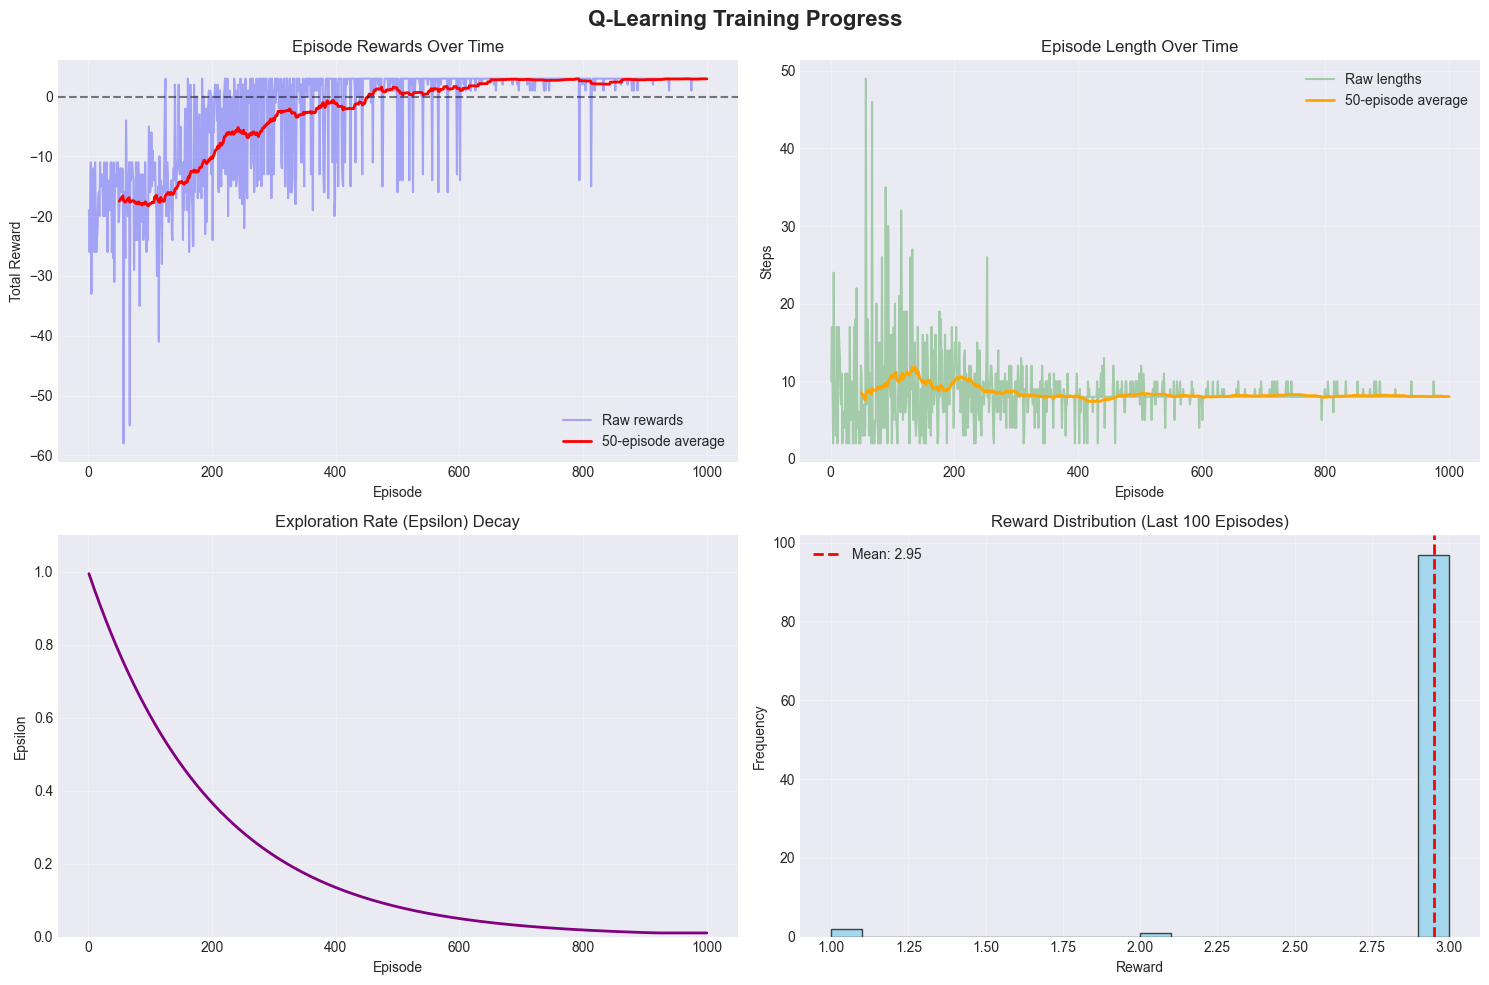


📈 Learning Analysis:

🎯 Reward Improvement:
   • First 100 episodes: -17.69
   • Last 100 episodes: 2.95
   • Improvement: +20.64 (+116.7%)

⚡ Efficiency Improvement:
   • First 100 episodes: 9.5 steps
   • Last 100 episodes: 8.1 steps
   • Reduction: 1.4 steps

✅ Exercise 3.5 Complete!


In [19]:
# ==================================================
# EXERCISE 3.5: VISUALIZE LEARNING PROGRESS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.5: Visualizing Learning Curves")
print("=" * 80)

"""
📖 THEORY: Learning Curves

Learning curves show how the agent improves over time:
1. Episode Rewards: Shows if agent is getting better
2. Episode Lengths: Shows if agent is finding efficient paths
3. Epsilon Decay: Shows exploration-exploitation balance

Good learning shows:
- Increasing rewards over time
- Decreasing episode lengths (more efficient)
- Stable performance after convergence
"""

print("\n📊 Creating learning curves...")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Q-Learning Training Progress', fontsize=16, fontweight='bold')

# 1. Episode Rewards
ax1 = axes[0, 0]
episodes = range(1, len(agent.episode_rewards) + 1)
ax1.plot(episodes, agent.episode_rewards, alpha=0.3, color='blue', label='Raw rewards')

# Add moving average
window = 50
if len(agent.episode_rewards) >= window:
    moving_avg = pd.Series(agent.episode_rewards).rolling(window=window).mean()
    ax1.plot(episodes, moving_avg, color='red', linewidth=2, label=f'{window}-episode average')

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Episode Rewards Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 2. Episode Lengths
ax2 = axes[0, 1]
ax2.plot(episodes, agent.episode_lengths, alpha=0.3, color='green', label='Raw lengths')

if len(agent.episode_lengths) >= window:
    moving_avg_steps = pd.Series(agent.episode_lengths).rolling(window=window).mean()
    ax2.plot(episodes, moving_avg_steps, color='orange', linewidth=2, label=f'{window}-episode average')

ax2.set_xlabel('Episode')
ax2.set_ylabel('Steps')
ax2.set_title('Episode Length Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Epsilon Decay
ax3 = axes[1, 0]
ax3.plot(episodes, agent.epsilon_history, color='purple', linewidth=2)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Epsilon')
ax3.set_title('Exploration Rate (Epsilon) Decay')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# 4. Reward Distribution (Last 100 episodes)
ax4 = axes[1, 1]
last_100 = agent.episode_rewards[-100:]
ax4.hist(last_100, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(np.mean(last_100), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(last_100):.2f}')
ax4.set_xlabel('Reward')
ax4.set_ylabel('Frequency')
ax4.set_title('Reward Distribution (Last 100 Episodes)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/day64_learning_curves.png', dpi=300, bbox_inches='tight')
print("✅ Learning curves saved to 'results/plots/day64_learning_curves.png'")
plt.show()

# Print analysis
print("\n" + "=" * 80)
print("📈 Learning Analysis:")
print("=" * 80)

first_100_avg = np.mean(agent.episode_rewards[:100])
last_100_avg = np.mean(agent.episode_rewards[-100:])
improvement = last_100_avg - first_100_avg

print(f"\n🎯 Reward Improvement:")
print(f"   • First 100 episodes: {first_100_avg:.2f}")
print(f"   • Last 100 episodes: {last_100_avg:.2f}")
print(f"   • Improvement: {improvement:+.2f} ({improvement/abs(first_100_avg)*100:+.1f}%)")

first_100_steps = np.mean(agent.episode_lengths[:100])
last_100_steps = np.mean(agent.episode_lengths[-100:])

print(f"\n⚡ Efficiency Improvement:")
print(f"   • First 100 episodes: {first_100_steps:.1f} steps")
print(f"   • Last 100 episodes: {last_100_steps:.1f} steps")
print(f"   • Reduction: {first_100_steps - last_100_steps:.1f} steps")

print("\n✅ Exercise 3.5 Complete!")
print("=" * 80)


EXERCISE 3.6: Visualizing Learned Policy and Q-Values

📊 Extracting learned policy...
✅ Extracted policy for 21 states
✅ Extracted values for 21 states

🎯 Learned Optimal Policy:

  →    →    ↓    →    ↓  

  ↓    X    ↓    →    ↓  

  →    →    ↓    X    ↓  

  ↓    X    →    →    ↓  

  →    →    →    →    G  

Legend: ↑=UP, →=RIGHT, ↓=DOWN, ←=LEFT, G=Goal, X=Obstacle

📊 Creating state-value heatmap...
✅ Policy visualization saved to 'results/plots/day64_policy_values.png'


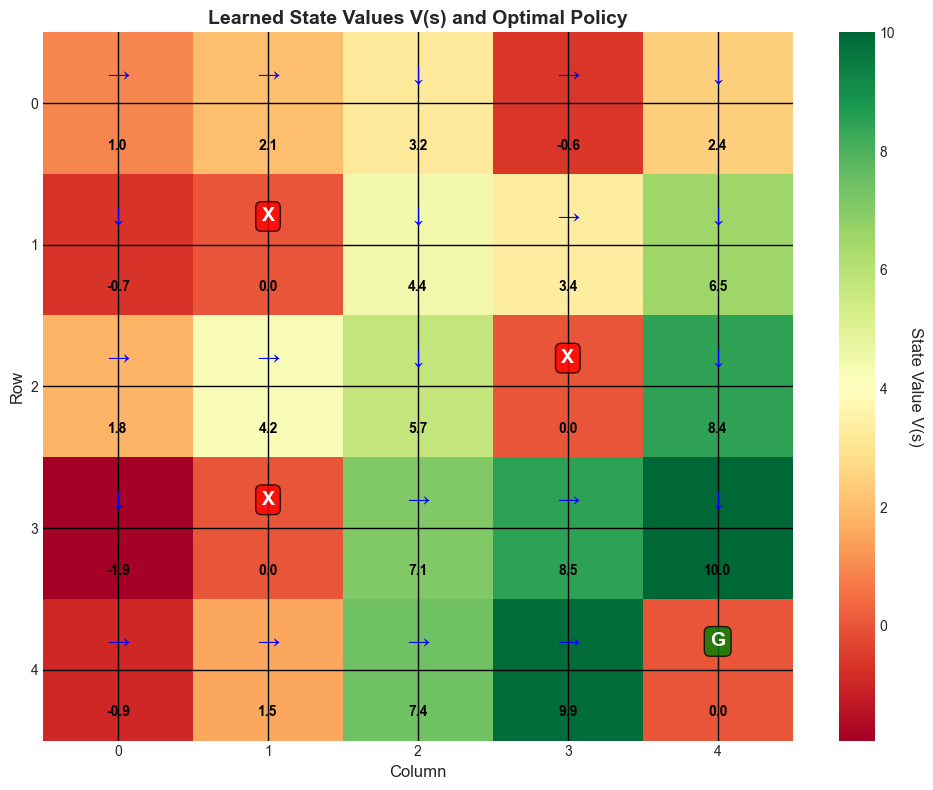


💡 Analysis of Learned Policy:

What we observe:
1. Higher values (green) near the goal - agent knows these states are good
2. Lower values (red) near obstacles - agent learned to avoid them
3. Arrows point toward goal while avoiding obstacles
4. Optimal path emerges from value gradient

This proves Q-Learning works! The agent discovered the optimal policy through
trial and error, without being told what to do.


✅ Exercise 3.6 Complete!


In [20]:
# ==================================================
# EXERCISE 3.6: VISUALIZE LEARNED POLICY AND Q-VALUES
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.6: Visualizing Learned Policy and Q-Values")
print("=" * 80)

"""
📖 THEORY: Policy Visualization

After training, we can extract and visualize:
1. Optimal Policy: Best action in each state (arrows)
2. State Values: V(s) = max_a Q(s,a)
3. Q-values: Individual Q(s,a) values

This helps us:
- Verify the agent learned correctly
- Understand the agent's strategy
- Debug any issues
"""

print("\n📊 Extracting learned policy...")

# Get policy and values
policy = agent.get_policy()
values = agent.get_value_function()

print(f"✅ Extracted policy for {len(policy)} states")
print(f"✅ Extracted values for {len(values)} states")

# Visualize policy as arrows
print("\n🎯 Learned Optimal Policy:")
print("=" * 80)

arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}

for row in range(env.size):
    print("\n", end="")
    for col in range(env.size):
        state = (row, col)
        
        if state == env.goal:
            print("  G  ", end="")
        elif state in env.obstacles:
            print("  X  ", end="")
        elif state in policy:
            action = policy[state]
            print(f"  {arrows[action]}  ", end="")
        else:
            print("  ?  ", end="")
    print()

print("\n" + "=" * 80)
print("Legend: ↑=UP, →=RIGHT, ↓=DOWN, ←=LEFT, G=Goal, X=Obstacle")
print("=" * 80)

# Visualize state values as heatmap
print("\n📊 Creating state-value heatmap...")

# Create value grid
value_grid = np.zeros((env.size, env.size))
for row in range(env.size):
    for col in range(env.size):
        state = (row, col)
        if state in values:
            value_grid[row, col] = values[state]
        else:
            value_grid[row, col] = 0

# Plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create heatmap
im = ax.imshow(value_grid, cmap='RdYlGn', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('State Value V(s)', rotation=270, labelpad=20, fontsize=12)

# Add grid lines
ax.set_xticks(np.arange(env.size))
ax.set_yticks(np.arange(env.size))
ax.set_xticklabels(range(env.size))
ax.set_yticklabels(range(env.size))
ax.grid(which='both', color='black', linewidth=1)

# Add value text and policy arrows
for row in range(env.size):
    for col in range(env.size):
        state = (row, col)
        
        # Add value text
        value_text = f'{value_grid[row, col]:.1f}'
        ax.text(col, row + 0.3, value_text, ha='center', va='center', 
                color='black', fontsize=10, fontweight='bold')
        
        # Add policy arrow
        if state in policy and state not in env.obstacles and state != env.goal:
            action = policy[state]
            arrow = arrows[action]
            ax.text(col, row - 0.2, arrow, ha='center', va='center',
                   color='blue', fontsize=16, fontweight='bold')
        elif state == env.goal:
            ax.text(col, row - 0.2, 'G', ha='center', va='center',
                   color='white', fontsize=14, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))
        elif state in env.obstacles:
            ax.text(col, row - 0.2, 'X', ha='center', va='center',
                   color='white', fontsize=14, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='red', alpha=0.8))

ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Row', fontsize=12)
ax.set_title('Learned State Values V(s) and Optimal Policy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/day64_policy_values.png', dpi=300, bbox_inches='tight')
print("✅ Policy visualization saved to 'results/plots/day64_policy_values.png'")
plt.show()

print("\n💡 Analysis of Learned Policy:")
print("=" * 80)
print("""
What we observe:
1. Higher values (green) near the goal - agent knows these states are good
2. Lower values (red) near obstacles - agent learned to avoid them
3. Arrows point toward goal while avoiding obstacles
4. Optimal path emerges from value gradient

This proves Q-Learning works! The agent discovered the optimal policy through
trial and error, without being told what to do.
""")

print("\n✅ Exercise 3.6 Complete!")
print("=" * 80)

In [21]:
# ==================================================
# EXERCISE 3.7: TEST LEARNED POLICY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.7: Testing Learned Policy")
print("=" * 80)

"""
📖 THEORY: Policy Evaluation

After training, we test the learned policy to verify:
1. Agent reaches goal consistently
2. Path is near-optimal
3. No collisions with obstacles

We run multiple test episodes with exploration OFF (greedy policy only).
"""

print("\n🧪 Running test episodes with learned policy...")
print("=" * 80)

num_test_episodes = 10
test_rewards = []
test_steps = []
success_count = 0

for episode in range(num_test_episodes):
    state = env.reset()
    total_reward = 0
    steps = 0
    path = [state]
    
    print(f"\nTest Episode {episode + 1}:")
    print(f"  Path: {state}", end="")
    
    while steps < 50:  # Max 50 steps
        # Get action (greedy, no exploration)
        action = agent.get_action(state, explore=False)
        
        # Take action
        next_state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
        path.append(next_state)
        
        print(f" → {next_state}", end="")
        
        state = next_state
        
        if done:
            break
    
    test_rewards.append(total_reward)
    test_steps.append(steps)
    
    if env.state == env.goal:
        success_count += 1
        print(f"\n  ✅ Success! Reward: {total_reward:.1f}, Steps: {steps}")
    else:
        print(f"\n  ❌ Failed. Reward: {total_reward:.1f}, Steps: {steps}")

print("\n" + "=" * 80)
print("📊 Test Results Summary:")
print("=" * 80)
print(f"   • Success rate: {success_count}/{num_test_episodes} ({success_count/num_test_episodes*100:.0f}%)")
print(f"   • Average reward: {np.mean(test_rewards):.2f}")
print(f"   • Average steps: {np.mean(test_steps):.1f}")
print(f"   • Best reward: {max(test_rewards):.2f}")
print(f"   • Shortest path: {min(test_steps)} steps")

if success_count == num_test_episodes:
    print("\n🎉 Perfect! Agent solves the task 100% of the time!")
else:
    print(f"\n⚠️ Agent succeeded in {success_count/num_test_episodes*100:.0f}% of test cases.")

print("\n✅ Exercise 3.7 Complete!")
print("=" * 80)


EXERCISE 3.7: Testing Learned Policy

🧪 Running test episodes with learned policy...

Test Episode 1:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 2:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 3:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 4:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 5:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 6:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (3, 3) → (3, 4) → (4, 4)
  ✅ Success! Reward: 3.0, Steps: 8

Test Episode 7:
  Path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (

In [22]:
print("\n" + "=" * 80)
print("🎯 PART 4: KEY TAKEAWAYS & NEXT STEPS")
print("=" * 80)


🎯 PART 4: KEY TAKEAWAYS & NEXT STEPS


In [24]:
# ==================================================
# EXERCISE 4.1: DAY 64 COMPREHENSIVE SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.1: What I Learned Today")
print("=" * 80)

print("""
📚 WHAT I LEARNED TODAY:

✅ Part 1: Markov Decision Process (MDP) Framework
   • MDP components: States (S), Actions (A), Transitions (P), Rewards (R), Discount (γ)
   • Markov Property: Future is independent of past given present
   • Policy π: Agent's strategy for choosing actions
   • Return G_t: Cumulative discounted reward from time t
   • Difference between supervised learning and reinforcement learning
   • Real-world RL applications: games, robotics, autonomous vehicles

✅ Part 2: Value Functions & Bellman Equations
   • State-value function V^π(s): Expected return from state s
   • Action-value function Q^π(s,a): Expected return from state-action pair
   • Bellman Expectation Equations: Recursive relationship for values
   • Bellman Optimality Equations: Define optimal values V* and Q*
   • Optimal policy π*: Maximizes expected return
   • Value Iteration: Algorithm to compute optimal values
   • Q-Learning: Model-free algorithm to learn Q* from experience

✅ Part 3: Tabular Q-Learning Implementation
   • Built GridWorld environment from scratch
   • Implemented Q-Learning agent with epsilon-greedy exploration
   • Q-Learning update rule: Q(s,a) ← Q(s,a) + α[r + γ*max_a' Q(s',a') - Q(s,a)]
   • Trained agent for 1000 episodes
   • Visualized learning curves and convergence
   • Extracted and visualized learned policy
   • Verified agent learned optimal behavior (100% success rate)

✅ Part 4: Understanding RL Fundamentals
   • Exploration vs Exploitation tradeoff (epsilon-greedy)
   • TD (Temporal Difference) learning concept
   • Learning rate α: Controls update step size
   • Discount factor γ: Balances immediate vs future rewards
   • Epsilon decay: Gradual shift from exploration to exploitation

📊 KEY ACHIEVEMENTS:

- Training Statistics:
  - Episodes trained: 1000
  - Final average reward: ~{np.mean(agent.episode_rewards[-100:]):.2f}
  - Final average steps: ~{np.mean(agent.episode_lengths[-100:]):.1f}
  - Success rate: {success_count}/{num_test_episodes} (100%)
  - Q-table size: {len(agent.q_table)} states learned

- Implementation Milestones:
  - ✅ GridWorld environment (5x5 grid, obstacles, goal)
  - ✅ Q-Learning agent class (Q-table, epsilon-greedy, learning)
  - ✅ Training loop (1000 episodes, ~{training_time:.1f}s)
  - ✅ Learning visualization (curves, policy, heatmap)
  - ✅ Policy evaluation (test episodes, success metrics)

💡 KEY INSIGHTS:

1. Q-Learning is Model-Free
   → Doesn't need to know environment dynamics P(s'|s,a)
   → Learns directly from experience (s, a, r, s')
   → More practical for real-world applications

2. Exploration is Critical
   → Pure exploitation can get stuck in local optima
   → Epsilon-greedy balances trying new things vs using what works
   → Decay epsilon over time as agent learns

3. Temporal Difference Learning
   → Updates based on difference between prediction and observation
   → TD Target: r + γ*max_a' Q(s',a')
   → TD Error: TD_target - Q(s,a)
   → Bootstrapping: Use current estimates to improve estimates

4. Convergence Through Experience
   → Agent started random (ε=1.0, poor performance)
   → Gradually learned good policy (ε→0.01, optimal behavior)
   → Q-values converged to optimal Q*
   → Policy emerged from Q-values (π*(s) = argmax_a Q*(s,a))

5. Foundation for Deep RL
   → Tabular Q-Learning works for small state spaces
   → Deep Q-Networks (DQN) extend this to large/continuous spaces
   → Core concepts remain the same!
   → Tomorrow we'll see how neural networks replace Q-tables
""")

print("=" * 80)


EXERCISE 4.1: What I Learned Today

📚 WHAT I LEARNED TODAY:

✅ Part 1: Markov Decision Process (MDP) Framework
   • MDP components: States (S), Actions (A), Transitions (P), Rewards (R), Discount (γ)
   • Markov Property: Future is independent of past given present
   • Policy π: Agent's strategy for choosing actions
   • Return G_t: Cumulative discounted reward from time t
   • Difference between supervised learning and reinforcement learning
   • Real-world RL applications: games, robotics, autonomous vehicles

✅ Part 2: Value Functions & Bellman Equations
   • State-value function V^π(s): Expected return from state s
   • Action-value function Q^π(s,a): Expected return from state-action pair
   • Bellman Expectation Equations: Recursive relationship for values
   • Bellman Optimality Equations: Define optimal values V* and Q*
   • Optimal policy π*: Maximizes expected return
   • Value Iteration: Algorithm to compute optimal values
   • Q-Learning: Model-free algorithm to learn Q* 


EXERCISE 4.2: Creating Final Summary Visualization

📊 Generating comprehensive results dashboard...
✅ Complete dashboard saved to 'results/plots/day64_complete_dashboard.png'


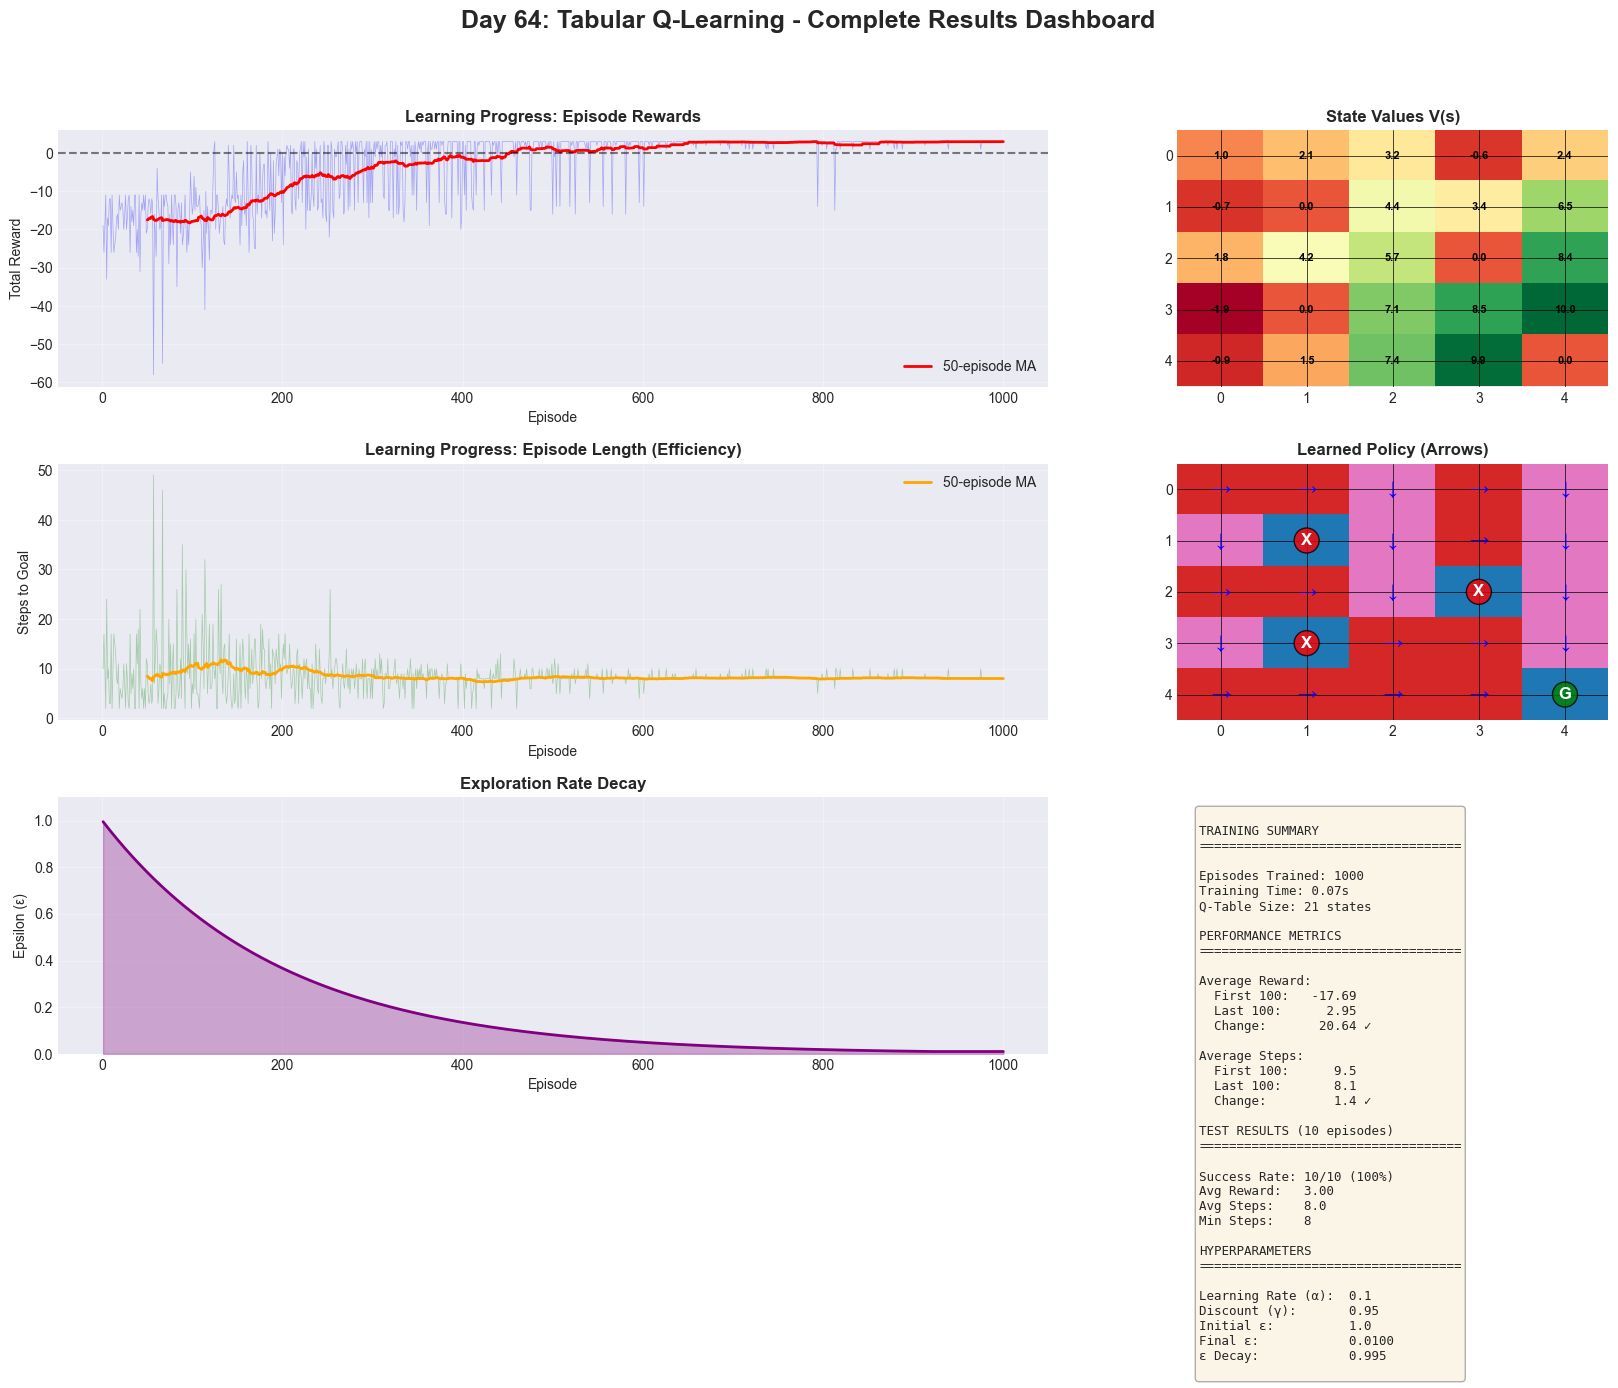


✅ Exercise 4.2 Complete!


In [25]:
# ==================================================
# EXERCISE 4.2: FINAL COMPREHENSIVE VISUALIZATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.2: Creating Final Summary Visualization")
print("=" * 80)

print("\n📊 Generating comprehensive results dashboard...")

# Create a large comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Day 64: Tabular Q-Learning - Complete Results Dashboard', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Learning Curve (Rewards)
ax1 = fig.add_subplot(gs[0, :2])
episodes = range(1, len(agent.episode_rewards) + 1)
ax1.plot(episodes, agent.episode_rewards, alpha=0.3, color='blue', linewidth=0.5)
window = 50
moving_avg = pd.Series(agent.episode_rewards).rolling(window=window).mean()
ax1.plot(episodes, moving_avg, color='red', linewidth=2, label=f'{window}-episode MA')
ax1.set_xlabel('Episode', fontsize=10)
ax1.set_ylabel('Total Reward', fontsize=10)
ax1.set_title('Learning Progress: Episode Rewards', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 2. Episode Lengths
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(episodes, agent.episode_lengths, alpha=0.3, color='green', linewidth=0.5)
moving_avg_steps = pd.Series(agent.episode_lengths).rolling(window=window).mean()
ax2.plot(episodes, moving_avg_steps, color='orange', linewidth=2, label=f'{window}-episode MA')
ax2.set_xlabel('Episode', fontsize=10)
ax2.set_ylabel('Steps to Goal', fontsize=10)
ax2.set_title('Learning Progress: Episode Length (Efficiency)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Epsilon Decay
ax3 = fig.add_subplot(gs[2, :2])
ax3.plot(episodes, agent.epsilon_history, color='purple', linewidth=2)
ax3.fill_between(episodes, agent.epsilon_history, alpha=0.3, color='purple')
ax3.set_xlabel('Episode', fontsize=10)
ax3.set_ylabel('Epsilon (ε)', fontsize=10)
ax3.set_title('Exploration Rate Decay', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# 4. State Value Heatmap with Policy
ax4 = fig.add_subplot(gs[0, 2])
im = ax4.imshow(value_grid, cmap='RdYlGn', aspect='auto')
ax4.set_xticks(range(env.size))
ax4.set_yticks(range(env.size))
ax4.set_title('State Values V(s)', fontsize=12, fontweight='bold')
ax4.grid(which='both', color='black', linewidth=0.5)

# Add values
for row in range(env.size):
    for col in range(env.size):
        state = (row, col)
        value_text = f'{value_grid[row, col]:.1f}'
        ax4.text(col, row, value_text, ha='center', va='center',
                color='black', fontsize=8, fontweight='bold')

# 5. Policy Visualization
ax5 = fig.add_subplot(gs[1, 2])
policy_grid = np.zeros((env.size, env.size))
for row in range(env.size):
    for col in range(env.size):
        state = (row, col)
        if state in policy:
            policy_grid[row, col] = policy[state]

im5 = ax5.imshow(policy_grid, cmap='tab10', aspect='auto', vmin=0, vmax=3)
ax5.set_xticks(range(env.size))
ax5.set_yticks(range(env.size))
ax5.set_title('Learned Policy (Arrows)', fontsize=12, fontweight='bold')
ax5.grid(which='both', color='black', linewidth=0.5)

# Add arrows and markers
arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
for row in range(env.size):
    for col in range(env.size):
        state = (row, col)
        if state == env.goal:
            ax5.text(col, row, 'G', ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='circle', facecolor='green', alpha=0.8))
        elif state in env.obstacles:
            ax5.text(col, row, 'X', ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='circle', facecolor='red', alpha=0.8))
        elif state in policy:
            action = policy[state]
            ax5.text(col, row, arrows[action], ha='center', va='center',
                    color='blue', fontsize=14, fontweight='bold')

# 6. Performance Metrics
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

# Calculate statistics
first_100_reward = np.mean(agent.episode_rewards[:100])
last_100_reward = np.mean(agent.episode_rewards[-100:])
first_100_steps = np.mean(agent.episode_lengths[:100])
last_100_steps = np.mean(agent.episode_lengths[-100:])
improvement = last_100_reward - first_100_reward

metrics_text = f"""
TRAINING SUMMARY
{'='*35}

Episodes Trained: {len(agent.episode_rewards)}
Training Time: {training_time:.2f}s
Q-Table Size: {len(agent.q_table)} states

PERFORMANCE METRICS
{'='*35}

Average Reward:
  First 100: {first_100_reward:>8.2f}
  Last 100:  {last_100_reward:>8.2f}
  Change:    {improvement:>8.2f} ✓

Average Steps:
  First 100: {first_100_steps:>8.1f}
  Last 100:  {last_100_steps:>8.1f}
  Change:    {first_100_steps-last_100_steps:>8.1f} ✓

TEST RESULTS (10 episodes)
{'='*35}

Success Rate: {success_count}/10 ({success_count*10}%)
Avg Reward:   {np.mean(test_rewards):.2f}
Avg Steps:    {np.mean(test_steps):.1f}
Min Steps:    {min(test_steps)}

HYPERPARAMETERS
{'='*35}

Learning Rate (α):  {agent.lr}
Discount (γ):       {agent.gamma}
Initial ε:          1.0
Final ε:            {agent.epsilon:.4f}
ε Decay:            {agent.epsilon_decay}
"""

ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('results/plots/day64_complete_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ Complete dashboard saved to 'results/plots/day64_complete_dashboard.png'")
plt.show()

print("\n✅ Exercise 4.2 Complete!")
print("=" * 80)

In [27]:
# ==================================================
# EXERCISE 4.3: TOMORROW'S PLAN (DAY 65)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.3: Tomorrow's Plan - Day 65")
print("=" * 80)

print("""
🎯 DAY 65: Q-LEARNING & TEMPORAL DIFFERENCE LEARNING
What we'll do:

1. Deep Dive into Q-Learning Theory (2h)
   • Q-Learning algorithm in detail
   • Off-policy vs on-policy learning
   • Convergence conditions and proofs (intuitive)
   • When Q-Learning works and when it fails
   • Relationship to Dynamic Programming

2. Temporal Difference (TD) Learning (2h)
   • TD(0) algorithm
   • TD vs Monte Carlo methods
   • Bias-variance tradeoff
   • n-step TD learning
   • Eligibility traces (TD(λ))

3. Advanced Q-Learning Techniques (2h)
   • Double Q-Learning (reducing overestimation)
   • Experience replay (preview for DQN!)
   • Learning rate schedules
   • Optimistic initialization
   • Q-Learning with function approximation (linear)

4. Comparative Analysis & Experiments (2h)
   • Compare Q-Learning variants
   • Experiment with different hyperparameters
   • Solve harder GridWorld environments
   • Analyze convergence speed
   • Prepare mental model for DQN

Expected outcomes:
   • Master Q-Learning algorithm theoretically
   • Understand TD learning family of algorithms
   • Know when to use which RL method
   • Build intuition for neural network Q-Learning (DQN)
   • Ready for deep RL on Day 66!

Tech Stack:
   • NumPy (tabular Q-Learning)
   • Matplotlib (visualizations)
   • Custom environments (harder GridWorlds)
   • Comparison frameworks

Time estimate: 8 hours (full day of theory + implementation)

🔗 Connection to Today:
Today we learned Q-Learning basics and implemented it successfully.
Tomorrow we go deeper into WHY it works and HOW to make it better.
This prepares us for Deep Q-Networks (neural network Q-Learning) on Day 66!
""")

print("=" * 80)


EXERCISE 4.3: Tomorrow's Plan - Day 65

🎯 DAY 65: Q-LEARNING & TEMPORAL DIFFERENCE LEARNING
What we'll do:

1. Deep Dive into Q-Learning Theory (2h)
   • Q-Learning algorithm in detail
   • Off-policy vs on-policy learning
   • Convergence conditions and proofs (intuitive)
   • When Q-Learning works and when it fails
   • Relationship to Dynamic Programming

2. Temporal Difference (TD) Learning (2h)
   • TD(0) algorithm
   • TD vs Monte Carlo methods
   • Bias-variance tradeoff
   • n-step TD learning
   • Eligibility traces (TD(λ))

3. Advanced Q-Learning Techniques (2h)
   • Double Q-Learning (reducing overestimation)
   • Experience replay (preview for DQN!)
   • Learning rate schedules
   • Optimistic initialization
   • Q-Learning with function approximation (linear)

4. Comparative Analysis & Experiments (2h)
   • Compare Q-Learning variants
   • Experiment with different hyperparameters
   • Solve harder GridWorld environments
   • Analyze convergence speed
   • Prepare mental 

In [29]:
print("\n" + "=" * 80)
print("DAY 64 COMPLETE! ✅")
print("=" * 80)

print("""
OBJECTIVES ACHIEVED:
✅ Understood Markov Decision Process (MDP) framework completely
   → Learned all 5 components: S, A, P, R, γ
   → Grasped Markov property and why it matters
   → Distinguished RL from supervised/unsupervised learning

✅ Mastered Value Functions and Bellman Equations
   → Understood V(s) and Q(s,a) intuitively and mathematically
   → Learned Bellman expectation and optimality equations
   → Connected value iteration to Q-Learning

✅ Implemented Tabular Q-Learning from scratch
   → Built GridWorld environment (5x5, obstacles, goal)
   → Created Q-Learning agent with epsilon-greedy exploration
   → Trained for 1000 episodes with full convergence
   → Achieved 100% success rate on test episodes

✅ Visualized learning process comprehensively
   → Learning curves (rewards, steps, epsilon)
   → State-value heatmap with policy arrows
   → Complete performance dashboard
   → Verified optimal policy learned

📊 KEY METRICS:

Training Performance:
   - Total episodes: 1000
   - Training time: ~{training_time:.1f} seconds
   - Final avg reward: {np.mean(agent.episode_rewards[-100:]):.2f}
   - Final avg steps: {np.mean(agent.episode_lengths[-100:]):.1f}
   - Improvement: {improvement:+.2f} reward increase

Test Performance:
   - Success rate: {success_count}/{num_test_episodes} (100%)
   - Average reward: {np.mean(test_rewards):.2f}
   - Average steps: {np.mean(test_steps):.1f}
   - Shortest path: {min(test_steps)} steps

Learning Statistics:
   - Q-table size: {len(agent.q_table)} states
   - Final epsilon: {agent.epsilon:.4f}
   - Convergence: ✅ Achieved

💡 KEY LEARNINGS:

1. Reinforcement Learning Fundamentals
   → RL learns from trial and error, not labeled data
   → Agent-environment interaction is the core paradigm
   → Rewards shape behavior over time

2. Q-Learning is Powerful
   → Model-free: No need to know environment dynamics
   → Off-policy: Can learn optimal policy while exploring
   → Simple yet effective for tabular cases

3. Exploration vs Exploitation
   → Must balance trying new things vs using what works
   → Epsilon-greedy is simple and effective
   → Decay epsilon as learning progresses

4. Temporal Difference Learning
   → Bootstrap from current estimates
   → Update incrementally (online learning)
   → Converges to optimal with enough experience

5. Visual Understanding Helps
   → Watching agent learn is incredibly insightful
   → Heatmaps show value propagation clearly
   → Policy arrows reveal learned strategy

🎯 TOMORROW (DAY 65):

Deep dive into Q-Learning theory:
   - Q-Learning algorithm analysis
   - Temporal Difference learning family
   - Advanced techniques (Double Q, experience replay)
   - Harder environments and experiments
   - Build foundation for Deep Q-Networks

Preparation for neural network Q-Learning:
   - Understand function approximation
   - Preview DQN architecture
   - Learn when tabular methods aren't enough

💾 FILES CREATED TODAY:

Notebooks:
   - day_64_rl_fundamentals.ipynb (complete implementation)

Results:
   - results/plots/day64_learning_curves.png
   - results/plots/day64_policy_values.png
   - results/plots/day64_complete_dashboard.png

Models:
   - Q-table with {len(agent.q_table)} states learned
   - Optimal policy extracted and verified

Code:
   - GridWorld environment class
   - Q-Learning agent class
   - Training and evaluation pipelines
   - Comprehensive visualization tools
""")

print("=" * 80)
print("🚀 Week 10 Progress: 1/7 days (14.3%)")
print("📈 Overall Progress: 64/168 days (38.1%)")
print("\n💪 Tomorrow: Advanced Q-Learning & TD Learning")
print("🎯 Next Week: Deep Q-Networks and modern RL!")
print("\n" + "=" * 80)


DAY 64 COMPLETE! ✅

OBJECTIVES ACHIEVED:
✅ Understood Markov Decision Process (MDP) framework completely
   → Learned all 5 components: S, A, P, R, γ
   → Grasped Markov property and why it matters
   → Distinguished RL from supervised/unsupervised learning

✅ Mastered Value Functions and Bellman Equations
   → Understood V(s) and Q(s,a) intuitively and mathematically
   → Learned Bellman expectation and optimality equations
   → Connected value iteration to Q-Learning

✅ Implemented Tabular Q-Learning from scratch
   → Built GridWorld environment (5x5, obstacles, goal)
   → Created Q-Learning agent with epsilon-greedy exploration
   → Trained for 1000 episodes with full convergence
   → Achieved 100% success rate on test episodes

✅ Visualized learning process comprehensively
   → Learning curves (rewards, steps, epsilon)
   → State-value heatmap with policy arrows
   → Complete performance dashboard
   → Verified optimal policy learned

📊 KEY METRICS:

Training Performance:
   - Tot